# Ellipse

Ellipses are used to summarize the orientation and spread of a point pattern.

In this notebook, the implementation of the ellipse in `pysal-pointpats` is described.

We make use of data sets from Ebdon, D. (1985) "Statistics in Geography" in to both test and illustrate the implementation.

In [5]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
# imports
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt


# Ebdon

In [7]:
points = [
    (1, 2),
    (2, 3),
    (2, 2),
    (2, 1),
    (3, 4),
    (3, 3),
    (3, 1),
    (4, 4) ]

We begin with the first point pattern consisting of eight points stored as a python list of tuples with each tuple containing the $x$ and $y$ coordinates for the point.

Next, we transform the points into a numpy array and then create a geopandas GeoSeries to facilitate subsequent analysis.

In [8]:
points = np.array(points)
geoms_epp = gpd.GeoSeries.from_xy(*points.T)

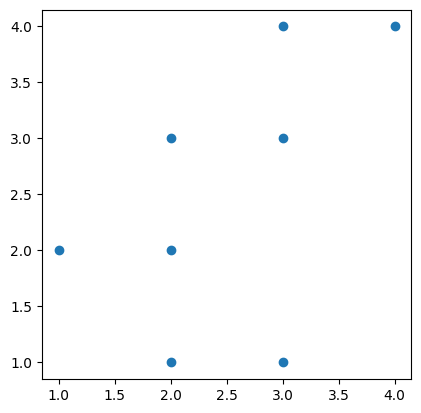

In [9]:
geoms_epp.plot();

The points are stretched out in a northeast orientation.

To capture this, the logic behind the ellipse is implemented in the following steps:

1. Shift the origin of the $x$ and $y$ axes to coincide with the center of the point pattern
2. Rotate the axes to find the maximum, and minimum, spread of the centered points.
3. Form the ellipse with a semi-major axis (semi-minor axis) equal to the standard deviation of the centered points around the rotated axes that maximize (minimizes) the sum of the deviations

We begin with the centering:

In [10]:
points.mean(axis=0)

array([2.5, 2.5])

In [11]:
xc, yc = points.mean(axis=0)

In [12]:
minx, miny, maxx, maxy = geoms_epp.total_bounds

In [13]:
from shapely.geometry import LineString

In [14]:
semi = np.sqrt( (maxx-xc )**2 + (maxy-yc )**2 )

In [15]:
xaxis = LineString( [(xc-semi, yc), (xc+semi, yc)])
yaxis = LineString( [(xc, yc-semi), (xc, yc+semi)])
axes = gpd.GeoSeries([xaxis, yaxis])

<Axes: >

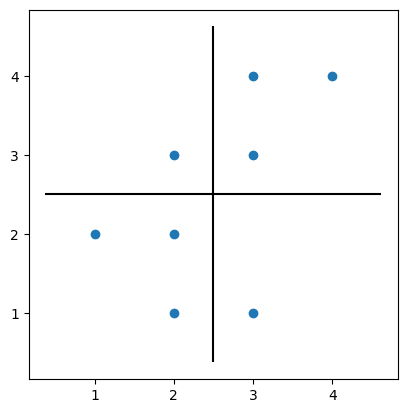

In [16]:
base = axes.plot(color='k')
geoms_epp.plot(ax=base)

With the origin now at the center of the point pattern, we will look for a rotation of these axes that maximizes the deviation of the points about the axes.
Before rotating, let us consider the deviations about the current axes. First, the deviations around the $y-axis$. These are given as $x_i - \bar{x}$.

In [17]:
xaxis.xy[0]

array('d', [0.3786796564403576, 4.621320343559642])

In [18]:
def project(point, segment):
    if isinstance(segment, LineString):
        segment = np.array(segment.coords)
    AB = segment[1] - segment[0]
    AC = point - segment[0]
    t = np.dot(AC, AB) / np.dot(AB, AB)
    t = max(0, min(1, t))
    p_x = segment[0][0] + t * AB[0]
    p_y = segment[0][1] + t * AB[1]
    return (p_x, p_y), t

In [19]:
project(np.array((1,2)), np.array(((2.5, 1.0), (2.5, 4))))

((np.float64(2.5), np.float64(2.0)), np.float64(0.3333333333333333))

In [20]:
xaxis.coords

In [21]:
project(np.array((1,2)), xaxis)

((np.float64(1.0), np.float64(2.5)), np.float64(0.14644660940672624))

In [22]:
[project(point, xaxis) for point in points]

[((np.float64(1.0), np.float64(2.5)), np.float64(0.14644660940672624)),
 ((np.float64(2.0), np.float64(2.5)), np.float64(0.38214886980224216)),
 ((np.float64(2.0), np.float64(2.5)), np.float64(0.38214886980224216)),
 ((np.float64(2.0), np.float64(2.5)), np.float64(0.38214886980224216)),
 ((np.float64(3.0), np.float64(2.5)), np.float64(0.6178511301977581)),
 ((np.float64(3.0), np.float64(2.5)), np.float64(0.6178511301977581)),
 ((np.float64(3.0), np.float64(2.5)), np.float64(0.6178511301977581)),
 ((np.float64(4.0), np.float64(2.5)), np.float64(0.853553390593274))]

0.39528470752104744


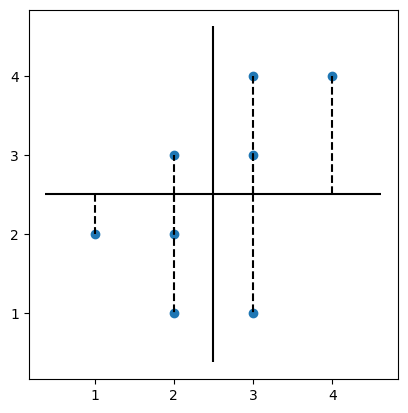

In [23]:
base = axes.plot(color='k')
geoms_epp.plot(ax=base)
n = points.shape[0]
d = 0
for point in points:
    pp,t = project(point, xaxis)
    plt.plot((pp[0], point[0]), (pp[1], point[1]), linestyle='--', color='k')
    d += (pp[1] - point[1])**2
print(np.sqrt(d)/n)
    

0.8660254037844386


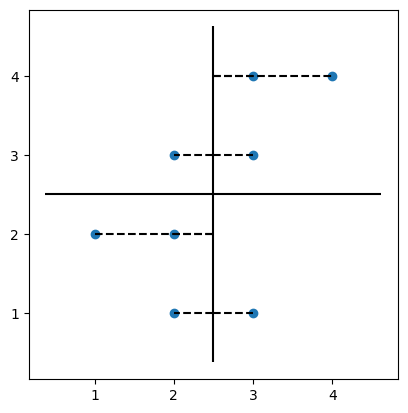

In [24]:
base = axes.plot(color='k')
geoms_epp.plot(ax=base)
d = 0
for point in points:
    pp,t = project(point, yaxis)
    plt.plot((pp[0], point[0]), (pp[1], point[1]), linestyle='--', color='k')
    d += (pp[0] - point[0])**2
print(np.sqrt(d/n))



In [25]:
import shapely

In [26]:
rxaxis = shapely.affinity.rotate(xaxis, -45, origin=(xc, yc))
ryaxis = shapely.affinity.rotate(yaxis, -45, origin=(xc, yc))

In [27]:
project(np.array((1,2)), rxaxis)

((np.float64(2.0), np.float64(3.0)), np.float64(0.33333333333333337))

In [28]:
project(np.array((1,2)), ryaxis)

((np.float64(1.5), np.float64(1.5000000000000002)),
 np.float64(0.1666666666666666))

<Axes: >

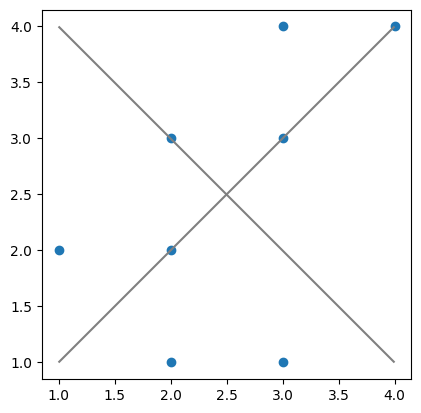

In [29]:
#base = axes.plot(color='k')
base = geoms_epp.plot()
gpd.GeoSeries([rxaxis, ryaxis]).plot(ax=base, color='grey')

1.2247448713915892


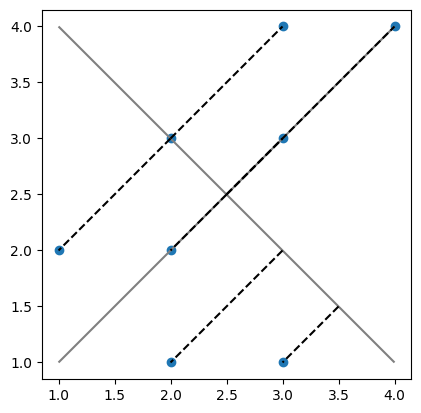

In [30]:
#base = axes.plot(color='k')
base = geoms_epp.plot()
gpd.GeoSeries([rxaxis, ryaxis]).plot(ax=base, color='grey')
d = 0
n, _ = points.shape
for point in points:
    pp,t = project(point, rxaxis)
    plt.plot((pp[0], point[0]), (pp[1], point[1]), linestyle='--', color='k')
    d += ((pp-point)**2).sum()
print(np.sqrt(d/n))

0.7071067811865476


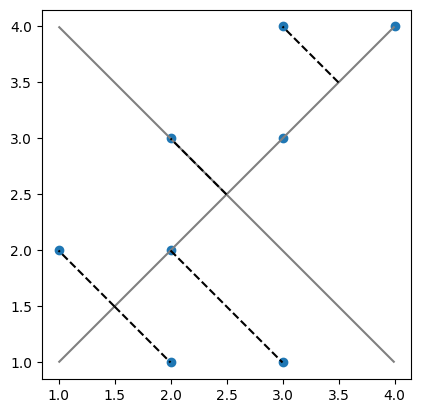

In [31]:
#base = axes.plot(color='k')
base = geoms_epp.plot()
gpd.GeoSeries([rxaxis, ryaxis]).plot(ax=base, color='grey')
d = 0
for point in points:
    pp,t = project(point, ryaxis)
    plt.plot((pp[0], point[0]), (pp[1], point[1]), linestyle='--', color='k')
    d += ((pp-point)**2).sum()
print(np.sqrt(d/n))


## Grid search on $\theta$

In [32]:
res = []
for theta in np.arange(-90, 100, 10):
    rxaxis = shapely.affinity.rotate(xaxis, theta, origin=(xc, yc))
    ryaxis = shapely.affinity.rotate(yaxis, theta, origin=(xc, yc))
    sx = sy = 0
    for point in points:
        pp,t = project(point, rxaxis)
        sx += ((pp-point)**2).sum()
        pp,t = project(point, ryaxis)
        sy += ((pp-point)**2).sum()
    res.append([theta, np.sqrt(sx/n), np.sqrt(sy/n)])
        
        

In [33]:
import pandas as pd
df = pd.DataFrame(data=res, columns=['theta', 'sx', 'sy'])

In [34]:
df

,theta,sx,sy
0,-90,0.866025,1.118034
1,-80,0.967516,1.031462
2,-70,1.062959,0.932801
3,-60,1.143684,0.831858
4,-50,1.203741,0.742299
5,-40,1.239280,0.681311
6,-30,1.248204,0.664821
7,-20,1.230002,0.697922
8,-10,1.185721,0.770757
9,0,1.118034,0.866025


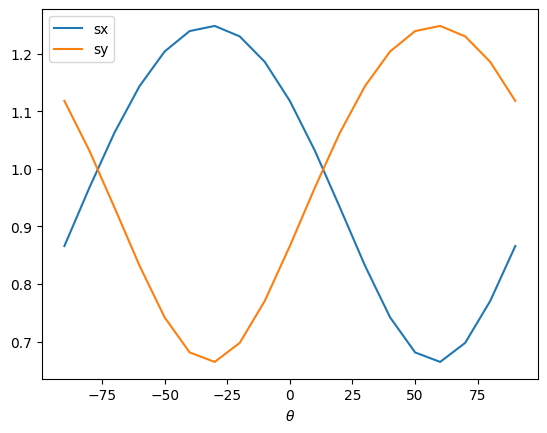

In [35]:
plt.plot(df.theta, df.sx, label='sx')
plt.plot(df.theta, df.sy, label='sy')
plt.xlabel(r'$\theta$')
plt.legend();

Several things to note about this plot

- sx and sy reflect each other
- maximum of sx is at -30 degrees which coincides with the minimum of sy
- maximum of sy is at 60 degrees which coincides with the minium of sx

## Ternary search

In [36]:
left = -50
right = -25
mid = (left+right) / 2
def obj(theta):
    sx = 0
    raxis = shapely.affinity.rotate(xaxis, theta, origin=(xc, yc))
    sx = 0
    for point in points:
        pp,t = project(point, raxis)
        sx += ((pp-point)**2).sum()
    return np.sqrt(sx/n)

def ternary_search(f, low, high, tol=1e-3):
    while (high - low) > tol:
        m1 = low + (high - low) / 3
        m2 = high - (high - low) / 3

        if f(m1) > f(m2):
            high=m2
        else:
            low = m1
    return (low + high) / 2

max_x = ternary_search(obj, -50, -25)

print(max_x)

-31.717472360972295


Step 0: Interval = (0.0000, 6.0000), m1: 2.0, m2: 4.0
Step 1: Interval = (2.0000, 6.0000), m1: 3.3, m2: 4.7
Step 2: Interval = (2.0000, 4.6667), m1: 2.9, m2: 3.8
Step 3: Interval = (2.0000, 3.7778), m1: 2.6, m2: 3.2
Step 4: Interval = (2.5926, 3.7778), m1: 3.0, m2: 3.4
Step 5: Interval = (2.5926, 3.3827), m1: 2.9, m2: 3.1
Step 6: Interval = (2.8560, 3.3827), m1: 3.0, m2: 3.2


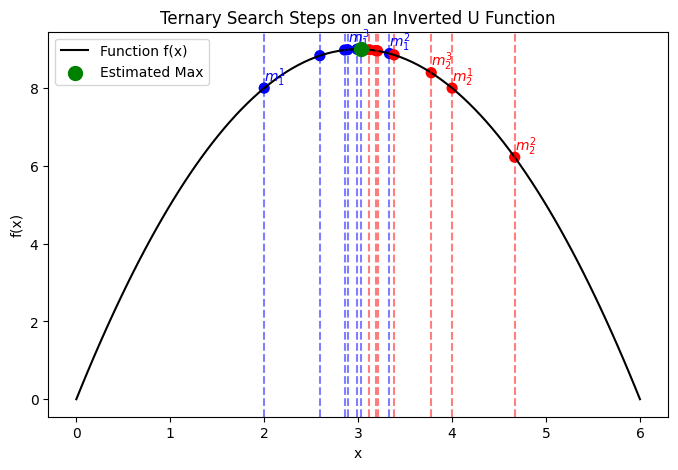

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    """ Example inverted U function with a single peak at x = 3 """
    return -(x - 3) ** 2 + 9  # Inverted U shape

def ternary_search_visualized(f, low, high, steps=10):
    """ Perform ternary search and visualize the steps """
    x_values = np.linspace(low, high, 100)
    y_values = f(x_values)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_values, y_values, label="Function f(x)", color="black")

    for i in range(steps):
        m1 = low + (high - low) / 3
        m2 = high - (high - low) / 3

        f_m1, f_m2 = f(m1), f(m2)

        # Plot search boundaries
        ax.axvline(m1, color="blue", linestyle="--", alpha=0.5)
        ax.axvline(m2, color="red", linestyle="--", alpha=0.5)
        print(f"Step {i}: Interval = ({low:.4f}, {high:.4f}), m1: {m1:.1f}, m2: {m2:.1f}")


        # Check which section to eliminate
        if f_m1 > f_m2:  
            high = m2  # Keep left section
        else:
            low = m1  # Keep right section


        # Annotate the first three steps
        if i < 3:
            ax.text(m1, f_m1, f"$m_1^{i+1}$", color="blue", fontsize=10, verticalalignment='bottom')
            ax.text(m2, f_m2, f"$m_2^{i+1}$", color="red", fontsize=10, verticalalignment='bottom')

        # Scatter plot points at midpoints
        ax.scatter([m1, m2], [f_m1, f_m2], color=["blue", "red"], s=50)

    # Final estimated max
    max_x = (low + high) / 2
    ax.scatter([max_x], [f(max_x)], color="green", s=100, label="Estimated Max", zorder=3)

    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.set_title("Ternary Search Steps on an Inverted U Function")
    ax.legend()
    plt.show()

# Run visualization
ternary_search_visualized(f, 0, 6, steps=7)





### Closed Form Solution for $\theta$

While the ternary search will lead us to the value of $\theta$ that maximizes dispersion around the rotated axis, there is an alternative route to the solution that is more efficient.

This is called a *closed-form* solution that we obtain  from solving an optimizion problem.

Our objective is to find the value of $\theta$ that when used to rotate the $y-axis$ results in the maximum dispersion of the point pattern around that rotated axis.

For a given value of $\theta$, we already know how to project the point at $(x_i, y_j)$ onto the rotated axis:

$$(x_p, y_p) = A + t AB$$

where

$AB$ is the length of the rotated $y-axis$, $A$ is the extreme value on that axis and
$$
t = AC . AB / (\left|AB \right | \left | AB \right |)
$$


[cos(30°) -sin(30°); sin(30°) cos(30°)]

https://www.cs.utexas.edu/~fussell/courses/cs384g-fall2011/lectures/lecture07-Affine.pdf

In [38]:
def rmat(a, t):
    r = [[a, 0, t[0]],
         [0, a, t[1]],
         [0, 0, 1]]
    
    
    return np.array(r)

In [39]:
t=np.array([1,2])

In [40]:
t.shape

(2,)

In [41]:
R = rmat(1, t)

In [42]:
R

array([[1, 0, 1],
       [0, 1, 2],
       [0, 0, 1]])

In [43]:
x = np.array([1,1, 1]).T

In [44]:
x.shape

(3,)

In [45]:
np.dot(R, x)

array([2, 3, 1])

In [46]:
np.cos(0)

np.float64(1.0)

In [47]:
np.sin(0)

np.float64(0.0)

In [48]:
def rmat(a, t):
    r = [[np.cos(a), -np.sin(a), t[0]],
         [np.sin(a), np.cos(a), t[1]],
         [0, 0, 1]]
    
    
    return np.array(r)

In [49]:
R = rmat(0, t)

In [50]:
R

array([[ 1., -0.,  1.],
       [ 0.,  1.,  2.],
       [ 0.,  0.,  1.]])

In [51]:
a = np.radians(45)
a

np.float64(0.7853981633974483)

In [52]:
R = rmat(np.radians(-45), np.array([0,0,1]).T)
R

array([[ 0.70710678,  0.70710678,  0.        ],
       [-0.70710678,  0.70710678,  0.        ],
       [ 0.        ,  0.        ,  1.        ]])

In [53]:
points = np.array([[xc, xc],
                 [yc-semi, yc+semi],
                 [1.0, 1.0]])

In [54]:
np.dot(R, points) # first row deviation in y second row deviation in x

array([[ 2.03553391,  5.03553391],
       [-1.5       ,  1.5       ],
       [ 1.        ,  1.        ]])

In [55]:
# Step 1: Compute the eigenvectors and eigenvalues of the covariance matrix

points = [
    (1, 2),
    (2, 3),
    (2, 2),
    (2, 1),
    (3, 4),
    (3, 3),
    (3, 1),
    (4, 4) ]
points = np.array(points)
# Step 1: Compute the mean center
x_mean = np.mean(points[:, 0])
y_mean = np.mean(points[:, 1])

# Step 2: Compute the second-order central moments
s_x2 = np.mean((points[:, 0] - x_mean) ** 2)
s_y2 = np.mean((points[:, 1] - y_mean) ** 2)
s_xy = np.mean((points[:, 0] - x_mean) * (points[:, 1] - y_mean))

# Step 3: Compute the rotation angle
theta = 0.5 * np.arctan2(2 * s_xy, s_x2 - s_y2)

# Convert angle to degrees
theta_degrees = np.degrees(theta)

# Display results
print(theta_degrees, theta)

cov_matrix = np.array([[s_x2, s_xy], [s_xy, s_y2]])
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Step 2: Rotate the points into the new coordinate system
# The eigenvectors form the rotation matrix
rotation_matrix = eigenvectors.T  # Transpose to align axes
rotated_points = (points - np.array([x_mean, y_mean])) @ rotation_matrix.T



# Step 3: Compute the covariance matrix of the rotated points
rotated_cov_matrix = np.cov(rotated_points, rowvar=False)

# Display the covariance matrix of the rotated points
import pandas as pd

rotated_cov_df = pd.DataFrame(rotated_cov_matrix, columns=["X'", "Y'"], index=["X'", "Y'"])


58.282525588538995 1.0172219678978514


In [56]:
np.cos(theta), np.sin(theta)

(np.float64(0.5257311121191336), np.float64(0.8506508083520399))

In [57]:
eigenvectors

array([[-0.85065081,  0.52573111],
       [ 0.52573111,  0.85065081]])

In [58]:
rotation_matrix.T

array([[-0.85065081,  0.52573111],
       [ 0.52573111,  0.85065081]])

In [59]:
import numpy as np

def your_function(points: np.ndarray) -> tuple[float, float, float]:
    n, _ = points.shape
    x = points[:, 0]
    y = points[:, 1]
    xd = x - x.mean()
    yd = y - y.mean()
    xss = (xd * xd).sum()
    yss = (yd * yd).sum()
    cv = (xd * yd).sum()
    
    theta = 0.5 * np.arctan2(2 * cv, xss - yss)  # More stable angle computation
    cos = np.cos(theta)
    sin = np.sin(theta)
    
    sx = np.sqrt((xss * cos**2 - 2 * cv * sin * cos + yss * sin**2) / n)
    sy = np.sqrt((xss * sin**2 + 2 * cv * sin * cos + yss * cos**2) / n)
    
    return sx, sy, theta

def eigenvector_method(points: np.ndarray) -> float:
    cov_matrix = np.cov(points.T, bias=True)  # Normalize by n
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # Ordered smallest to largest
    major_axis_vector = eigvecs[:, 1]  # Largest eigenvalue's eigenvector
    theta_eigen = np.arctan2(major_axis_vector[1], major_axis_vector[0])
    
    return theta_eigen

# Test with a sample point pattern
points = np.random.randn(100, 2)  # Random 2D points

theta_your_func = your_function(points)[2]
theta_eigen = eigenvector_method(points)

print(f"Your function's theta: {np.degrees(theta_your_func):.2f}°")
print(f"Eigenvector method's theta: {np.degrees(theta_eigen):.2f}°")
print(f"Angle difference: {np.degrees(theta_your_func - theta_eigen):.2f}°")


Your function's theta: 26.10°
Eigenvector method's theta: -153.90°
Angle difference: 180.00°


In [60]:
import numpy as np

def your_function(points: np.ndarray) -> tuple[float, float, float]:
    n, _ = points.shape
    x = points[:, 0]
    y = points[:, 1]
    xd = x - x.mean()
    yd = y - y.mean()
    xss = (xd * xd).sum()
    yss = (yd * yd).sum()
    cv = (xd * yd).sum()
    
    theta = 0.5 * np.arctan2(2 * cv, xss - yss)  # More stable angle computation
    cos = np.cos(theta)
    sin = np.sin(theta)
    
    sx = np.sqrt((xss * cos**2 - 2 * cv * sin * cos + yss * sin**2) / n)
    sy = np.sqrt((xss * sin**2 + 2 * cv * sin * cos + yss * cos**2) / n)
    
    return sx, sy, theta

def eigenvector_method(points: np.ndarray) -> tuple[float, float, float]:
    """
    Computes the standard deviational ellipse parameters using eigenvalues and eigenvectors.

    Parameters:
        points (np.ndarray): An (N,2) array of point coordinates.

    Returns:
        sx (float): Standard deviation along the major axis (semi-major axis).
        sy (float): Standard deviation along the minor axis (semi-minor axis).
        theta (float): Rotation angle in radians (angle of the major axis).
    """
    # Compute the covariance matrix
    cov_matrix = np.cov(points.T, bias=True)  # Normalized by N instead of N-1
    
    # Compute eigenvalues and eigenvectors
    eigvals, eigvecs = np.linalg.eigh(cov_matrix)  # Sorted smallest to largest

    # Semi-major and semi-minor axes (square root of eigenvalues)
    sx = np.sqrt(eigvals[1])  # Major axis (largest eigenvalue)
    sy = np.sqrt(eigvals[0])  # Minor axis (smallest eigenvalue)

    # Orientation of the major axis (from the eigenvector)
    major_axis_vector = eigvecs[:, 1]  # Corresponds to largest eigenvalue
    theta = np.arctan2(major_axis_vector[1], major_axis_vector[0])  # Eigenvector angle

    return sx, sy, theta



# Test with a sample point pattern

points = [
    (1, 2),
    (2, 3),
    (2, 2),
    (2, 1),
    (3, 4),
    (3, 3),
    (3, 1),
    (4, 4) ]
points = np.array(points)
sx, sy, theta_your_func = your_function(points)
sxe, sye, theta_eigen = eigenvector_method(points)

# Normalize angle difference to within [-90°, 90°] or [0°, 180°]
theta_diff = np.degrees(theta_your_func - theta_eigen)
if theta_diff > 90:
    theta_diff -= 180
elif theta_diff < -90:
    theta_diff += 180

print(f"Your function's theta: {np.degrees(theta_your_func):.2f}°")
print(f"Eigenvector method's theta: {np.degrees(theta_eigen):.2f}°")
print(f"Angle difference (adjusted): {theta_diff:.2f}°")


Your function's theta: 58.28°
Eigenvector method's theta: 58.28°
Angle difference (adjusted): 0.00°


In [61]:
sx, sxe

(np.float64(0.815223775030532), np.float64(1.2486060204784164))

In [62]:
sy, sye

(np.float64(1.1555994966358234), np.float64(0.6640655130520275))

In [63]:
sy * np.sqrt(2)

np.float64(1.6342644808139033)

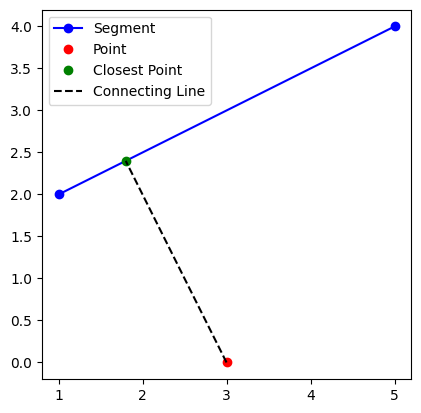

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point

def closest_point_on_segment(segment, point):
    """
    Find the closest point on a line segment to a given point.
    
    Parameters:
        segment: tuple of two points (x1, y1), (x2, y2)
        point: tuple (px, py)
    
    Returns:
        Closest point (cx, cy) on the segment
    """
    p1, p2 = np.array(segment[0]), np.array(segment[1])
    p = np.array(point)
    
    # Vector from p1 to p2
    v = p2 - p1
    v_len_squared = np.dot(v, v)
    
    # Projection scalar of p onto the line
    t = np.dot(p - p1, v) / v_len_squared
    
    # Clamp t to stay within segment
    t = max(0, min(1, t))
    
    # Compute closest point
    closest = p1 + t * v
    return tuple(closest)

# Define segment and point
segment = ((1, 2), (5, 4))
point = (3, 0)

# Get closest point on segment
closest = closest_point_on_segment(segment, point)

# Plot
fig, ax = plt.subplots()
ax.plot(*zip(*segment), 'bo-', label="Segment")  # Plot segment
ax.plot(*point, 'ro', label="Point")  # Given point
ax.plot(*closest, 'go', label="Closest Point")  # Projection on segment
ax.plot([point[0], closest[0]], [point[1], closest[1]], 'k--', label="Connecting Line")  # Shortest line

ax.legend()
ax.set_aspect('equal')
plt.show()


In [65]:
closest_point_on_segment(rxaxis.xy, (3,2))

(np.float64(2.5), np.float64(2.5))

In [66]:
closest_point_on_segment(ryaxis.xy, (3,2))

(np.float64(3.0), np.float64(2.0))

In [67]:
cpx = [closest_point_on_segment(rxaxis.xy, p) for p in points]

In [68]:
cpy = [closest_point_on_segment(ryaxis.xy, p) for p in points]

In [69]:
cpx

[(np.float64(1.9999999999999998), np.float64(3.0)),
 (np.float64(2.0), np.float64(3.0)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.0), np.float64(3.0)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5))]

In [70]:
cpy

[(np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(3.0), np.float64(2.0)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(2.5), np.float64(2.5)),
 (np.float64(3.5), np.float64(1.5)),
 (np.float64(2.5), np.float64(2.5))]

In [71]:
points

array([[1, 2],
       [2, 3],
       [2, 2],
       [2, 1],
       [3, 4],
       [3, 3],
       [3, 1],
       [4, 4]])

In [72]:
from shapely.geometry import Point

<Axes: >

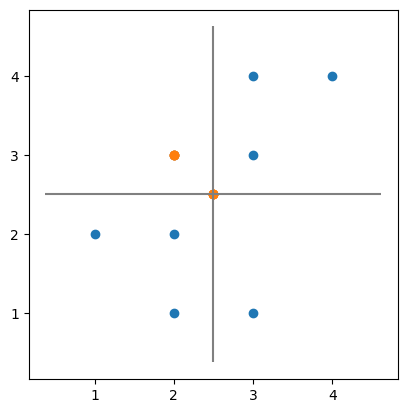

In [73]:
#base = axes.plot(color='k')
base = geoms_epp.plot()
gpd.GeoSeries([rxaxis, ryaxis]).plot(ax=base, color='grey')
gpd.GeoSeries([Point(p) for p in cpx]).plot(ax=base)

In [74]:
from pointpats import ellipse

In [75]:
ellipse(points)

(np.float64(0.6640655130520275),
 np.float64(1.2486060204784164),
 np.float64(-0.5535743588970453))

In [76]:
np.degrees(ellipse(points)[-1])

np.float64(-31.71747441146101)

In [77]:
gellipse = ellipse(geoms_epp)

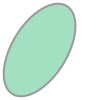

In [78]:
gellipse

<Axes: >

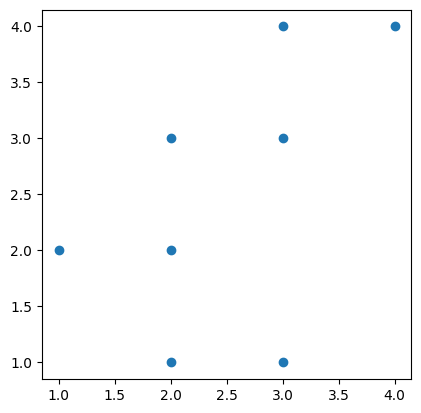

In [79]:
geoms_epp.plot()

In [80]:
egdf = gpd.GeoSeries([gellipse])

<Axes: >

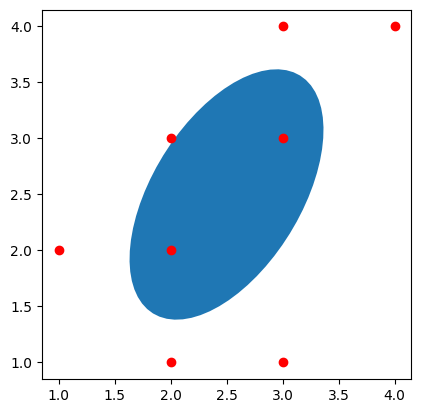

In [81]:
base = egdf.plot()
geoms_epp.plot(ax=base, color='r')

In [82]:
sx, sy, theta = ellipse(points)

In [83]:
sx, sy

(np.float64(0.6640655130520275), np.float64(1.2486060204784164))

In [84]:
xc, yc = points.mean(axis=0)

In [85]:
from shapely.geometry import LineString

<Axes: >

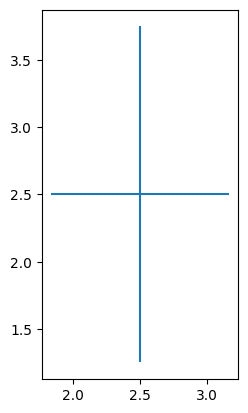

In [86]:
yaxis = LineString([(xc, yc-sy), (xc, yc+sy)])
xaxis = LineString([(xc-sx, yc), (xc+sx, yc)])
axes = gpd.GeoSeries([yaxis, xaxis])
axes.plot()

<Axes: >

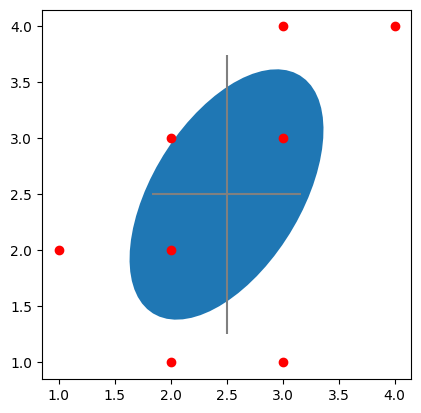

In [87]:
base = egdf.plot()
geoms_epp.plot(ax=base, color='r')
axes.plot(ax=base, color='grey')

<Axes: >

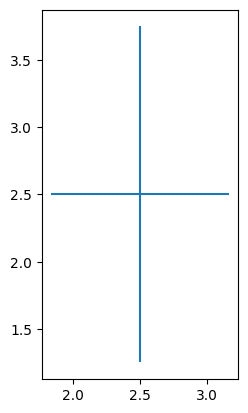

In [88]:
yaxis = LineString([(xc, yc-sy), (xc, yc+sy)])
xaxis = LineString([(xc-sx, yc), (xc+sx, yc)])
axes = gpd.GeoSeries([yaxis, xaxis])
axes.plot()

In [89]:
import shapely

In [90]:
ryaxis = shapely.affinity.rotate(yaxis, theta, use_radians=True)

In [91]:
rxasis = shapely.affinity.rotate(xaxis, theta, use_radians=True)

In [92]:
raxes = gpd.GeoSeries([ryaxis, rxasis])

<Axes: >

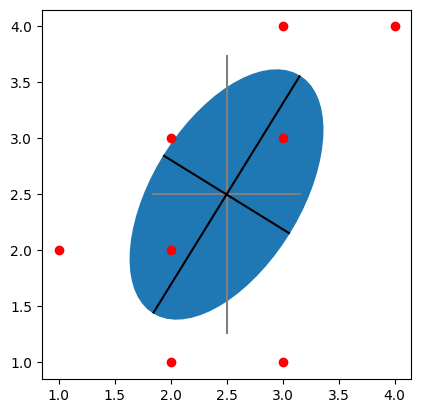

In [93]:
base = egdf.plot()
geoms_epp.plot(ax=base, color='r')
axes.plot(ax=base, color='grey')
raxes.plot(ax=base, color='k')

### Ellipse 2 from Ebdon

In [94]:
points = [
    (3, 4),
    (3, 9),
    (4, 7),
    (5, 5),
    (6, 3),
    (7, 1),
    (7, 6)
]
points = np.array(points)

In [95]:
points = [
    (3, 4),
    (3, 9),
    (4, 7),
    (5, 5),
    (6, 3),
    (7, 1),
    (7, 6)
]
points = np.array(points)

In [96]:
ep = ellipse(points)

In [97]:
ep

(np.float64(2.6726124191242437),
 np.float64(1.1952286093343936),
 np.float64(-1.1071487177940904))

In [98]:
geoms_epp = gpd.GeoSeries.from_xy(*points.T)

In [99]:
gellipse = ellipse(geoms_epp)

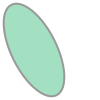

In [100]:
gellipse

In [101]:
def plot_ellipse(points):
    sx, sy, theta = ellipse(points)
    pgs = gpd.GeoSeries.from_xy(*points.T)
    gellipse = ellipse(pgs)
    egs = gpd.GeoSeries([gellipse])
    base = egs.plot()
    pgs.plot(ax=base, color='r')
    xc, yc = points.mean(axis=0)
    yaxis = LineString([(xc, yc-sy), (xc, yc+sy)])
    xaxis = LineString([(xc-sx, yc), (xc+sx, yc)])
    ryaxis = shapely.affinity.rotate(yaxis, theta, use_radians=True)
    rxaxis = shapely.affinity.rotate(xaxis, theta, use_radians=True)
    ags = gpd.GeoSeries([rxaxis, ryaxis])
    ags.plot(ax=base, color='k')

    
    

In [102]:
from matplotlib.patches import Arc
import matplotlib.pyplot as plt

In [103]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Arc
from matplotlib.transforms import Bbox, IdentityTransform, TransformedBbox


class AngleAnnotation(Arc):
    """
    Draws an arc between two vectors which appears circular in display space.
    """
    def __init__(self, xy, p1, p2, size=75, unit="points", ax=None,
                 text="", textposition="inside", text_kw=None, **kwargs):
        """
        Parameters
        ----------
        xy, p1, p2 : tuple or array of two floats
            Center position and two points. Angle annotation is drawn between
            the two vectors connecting *p1* and *p2* with *xy*, respectively.
            Units are data coordinates.

        size : float
            Diameter of the angle annotation in units specified by *unit*.

        unit : str
            One of the following strings to specify the unit of *size*:

            * "pixels": pixels
            * "points": points, use points instead of pixels to not have a
              dependence on the DPI
            * "axes width", "axes height": relative units of Axes width, height
            * "axes min", "axes max": minimum or maximum of relative Axes
              width, height

        ax : `matplotlib.axes.Axes`
            The Axes to add the angle annotation to.

        text : str
            The text to mark the angle with.

        textposition : {"inside", "outside", "edge"}
            Whether to show the text in- or outside the arc. "edge" can be used
            for custom positions anchored at the arc's edge.
v
        text_kw : dict
            Dictionary of arguments passed to the Annotation.

        **kwargs
            Further parameters are passed to `matplotlib.patches.Arc`. Use this
            to specify, color, linewidth etc. of the arc.

        """
        self.ax = ax or plt.gca()
        self._xydata = xy  # in data coordinates
        self.vec1 = p1
        self.vec2 = p2
        self.size = size
        self.unit = unit
        self.textposition = textposition

        super().__init__(self._xydata, size, size, angle=0.0,
                         theta1=self.theta1, theta2=self.theta2, **kwargs)

        self.set_transform(IdentityTransform())
        self.ax.add_patch(self)

        self.kw = dict(ha="center", va="center",
                       xycoords=IdentityTransform(),
                       xytext=(0, 0), textcoords="offset points",
                       annotation_clip=True)
        self.kw.update(text_kw or {})
        self.text = ax.annotate(text, xy=self._center, **self.kw)

    def get_size(self):
        factor = 1.
        if self.unit == "points":
            factor = self.ax.figure.dpi / 72.
        elif self.unit[:4] == "axes":
            b = TransformedBbox(Bbox.unit(), self.ax.transAxes)
            dic = {"max": max(b.width, b.height),
                   "min": min(b.width, b.height),
                   "width": b.width, "height": b.height}
            factor = dic[self.unit[5:]]
        return self.size * factor

    def set_size(self, size):
        self.size = size

    def get_center_in_pixels(self):
        """return center in pixels"""
        return self.ax.transData.transform(self._xydata)

    def set_center(self, xy):
        """set center in data coordinates"""
        self._xydata = xy

    def get_theta(self, vec):
        vec_in_pixels = self.ax.transData.transform(vec) - self._center
        return np.rad2deg(np.arctan2(vec_in_pixels[1], vec_in_pixels[0]))

    def get_theta1(self):
        return self.get_theta(self.vec1)

    def get_theta2(self):
        return self.get_theta(self.vec2)

    def set_theta(self, angle):
        pass

    # Redefine attributes of the Arc to always give values in pixel space
    _center = property(get_center_in_pixels, set_center)
    theta1 = property(get_theta1, set_theta)
    theta2 = property(get_theta2, set_theta)
    width = property(get_size, set_size)
    height = property(get_size, set_size)

    # The following two methods are needed to update the text position.
    def draw(self, renderer):
        self.update_text()
        super().draw(renderer)

    def update_text(self):
        c = self._center
        s = self.get_size()
        angle_span = (self.theta2 - self.theta1) % 360
        angle = np.deg2rad(self.theta1 + angle_span / 2)
        r = s / 2
        if self.textposition == "inside":
            r = s / np.interp(angle_span, [60, 90, 135, 180],
                                          [3.3, 3.5, 3.8, 4])
        self.text.xy = c + r * np.array([np.cos(angle), np.sin(angle)])
        if self.textposition == "outside":
            def R90(a, r, w, h):
                if a < np.arctan(h/2/(r+w/2)):
                    return np.sqrt((r+w/2)**2 + (np.tan(a)*(r+w/2))**2)
                else:
                    c = np.sqrt((w/2)**2+(h/2)**2)
                    T = np.arcsin(c * np.cos(np.pi/2 - a + np.arcsin(h/2/c))/r)
                    xy = r * np.array([np.cos(a + T), np.sin(a + T)])
                    xy += np.array([w/2, h/2])
                    return np.sqrt(np.sum(xy**2))

            def R(a, r, w, h):
                aa = (a % (np.pi/4))*((a % (np.pi/2)) <= np.pi/4) + \
                     (np.pi/4 - (a % (np.pi/4)))*((a % (np.pi/2)) >= np.pi/4)
                return R90(aa, r, *[w, h][::int(np.sign(np.cos(2*a)))])

            bbox = self.text.get_window_extent()
            X = R(angle, r, bbox.width, bbox.height)
            trans = self.ax.figure.dpi_scale_trans.inverted()
            offs = trans.transform(((X-s/2), 0))[0] * 72
            self.text.set_position([offs*np.cos(angle), offs*np.sin(angle)])

In [104]:
def plot_ellipse(points):
    sx, sy, theta = ellipse(points)
    pgs = gpd.GeoSeries.from_xy(*points.T)
    gellipse = ellipse(pgs)
    egs = gpd.GeoSeries([gellipse])
    fig, ax = plt.subplots(1,1, figsize=(6, 6))

    egs.plot(ax=ax)
    pgs.plot(ax=ax, color='r')
    xc, yc = points.mean(axis=0)
    minx, miny, maxx, maxy = pgs.total_bounds
    mmx = max(maxx, maxy)
    
    yaxis = LineString([(xc, yc-sy), (xc, yc+sy)])
    xaxis = LineString([(xc-sx, yc), (xc+sx, yc)])
    ryaxis = shapely.affinity.rotate(yaxis, theta, use_radians=True)
    rxaxis = shapely.affinity.rotate(xaxis, theta, use_radians=True)
    yaxis = LineString([(xc, miny), (xc, maxy)])
    xaxis = LineString([(1, yc), (mmx, yc)])
    oxs = gpd.GeoSeries([xaxis, yaxis])
    oxs.plot(ax=ax, color='grey')
    ags = gpd.GeoSeries([rxaxis, ryaxis])
    ags.plot(ax=ax, color='grey')
    degrees = np.degrees(theta)

    p1 = [ (xc, miny), (xc, maxy) ]
    yrx, yry = ryaxis.coords.xy
    p2 = [ (yrx[0], yry[0]), (yrx[1] , yry[1] ) ]
    am1 = AngleAnnotation((xc, yc), p2[1], p1[1], ax=ax, text=r"$\theta$")

    plt.text(minx, maxy, rf"$\theta={degrees:.1f}^\circ$", color='k', fontsize=12)
    #arc = Arc((xc, yc), sy, sy, angle=0, theta1=90+degrees, theta2=90,
    #      edgecolor="red", lw=2)

    #ax.add_patch(arc)
    #ax.plot([.5],[.5],marker=r'$\circlearrowleft$',ms=100)

    #ax.plot([xc, sy], marker=r'$\circlearrowright$', ms=100)

    start = shapely.geometry.Point((xc, yc+sx))
    end = shapely.affinity.rotate(start, angle=theta, origin=(xc, yc), use_radians=True)
    print(start)
    print(end)
    ax.annotate('',
                xy=(xc + sx, maxy),
                xytext=(xc, maxy),
                arrowprops=dict(facecolor='red'),
                horizontalalignment='right', verticalalignment='bottom'
            )  # clip to the axes bounding box

    # adjust for https://matplotlib.org/stable/gallery/text_labels_and_annotations/angle_annotation.html#sphx-glr-gallery-text-labels-and-annotations-angle-annotation-py
    

POINT (5 7.672612419124244)
POINT (7.390457218668788 6.195228609334395)


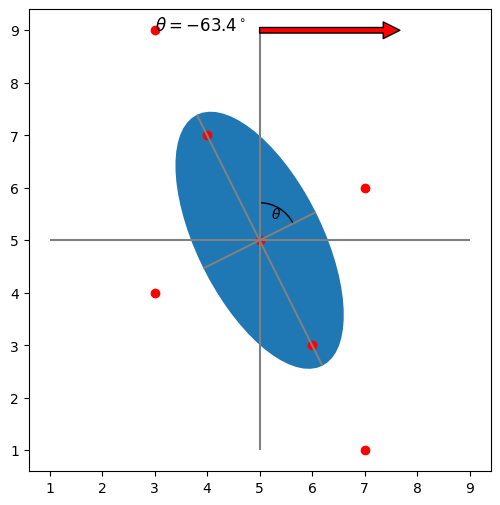

In [105]:
plot_ellipse(points)

In [106]:
points = np.array([
    (1, 2),
    (2, 3),
    (2, 2),
    (2, 1),
    (3, 4),
    (3, 3),
    (3, 1),
    (4, 4) ])

In [107]:
ellipse(points)

(np.float64(0.6640655130520275),
 np.float64(1.2486060204784164),
 np.float64(-0.5535743588970453))

POINT (2.5 3.1640655130520274)
POINT (2.8491199006968055 3.0648878654764196)


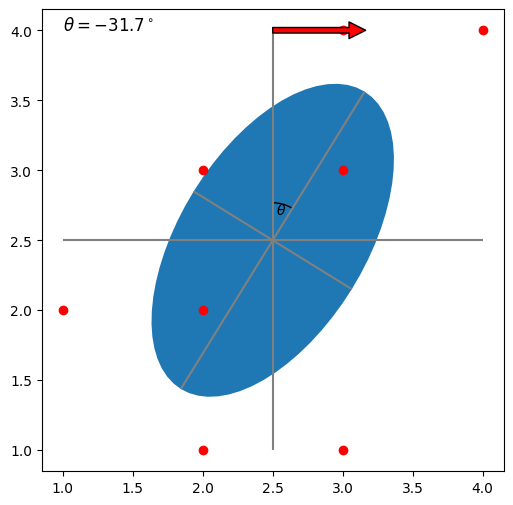

In [108]:
plot_ellipse(points)

In [109]:
points = [
    (3, 4),
    (3, 9),
    (4, 7),
    (5, 5),
    (6, 3),
    (7, 1),
    (7, 6)
]
points = np.array(points)

POINT (5 7.672612419124244)
POINT (7.390457218668788 6.195228609334395)


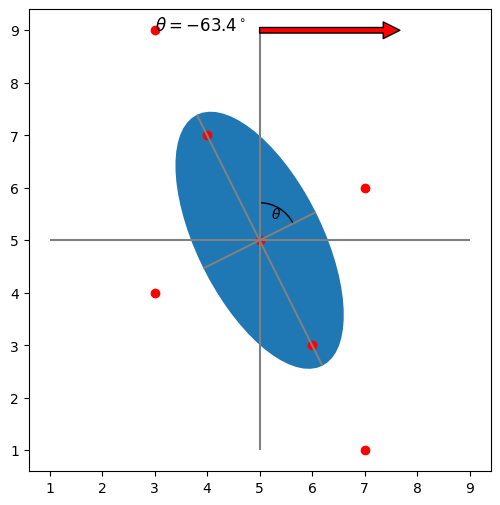

In [110]:
plot_ellipse(points)

In [111]:
gellipse.centroid.coords.xy


(array('d', [4.999999999999999]), array('d', [5.000000000000002]))

In [112]:
np.degrees(ep[-1])

np.float64(-63.43494882292201)

In [113]:
gellipse.area

10.019336627978685

In [114]:
from pointpats import *

In [115]:
from pointpats import std_distance

In [116]:
points = [
    (1, 2),
    (2, 3),
    (2, 2),
    (2, 1),
    (3, 4),
    (3, 3),
    (3, 1),
    (4, 4) ]

In [117]:
euclidean_median(points)

array([2.34998979, 2.48670953])

In [118]:
mbc = minimum_bounding_circle(points)

In [119]:
mbc

((2.642857142857143, 2.7857142857142856), np.float64(1.821078397711709))

In [120]:
weighted_mean_center(points, [1,2,3,4,5,6,7,8])


array([2.91666667, 2.63888889])

In [121]:
weighted_mean_center(points, np.tile([1, 2], 4))

array([2.58333333, 2.58333333])

In [122]:
std_distance(points)

np.float64(1.4142135623730951)

In [123]:
dtot([20, 30], points)

np.float64(260.82124947048817)

In [124]:
manhattan_median(points)

/home/serge/para/1_projects/dev-pointpats/pointpats/pointpats/centrography.py:505: UserWarning: Manhattan Median is not unique for even point patterns.
  return manhattan_median(points)


array([2.5, 2.5])

In [125]:
from pointpats.centrography import minimum_rotated_rectangle

In [126]:
minimum_rotated_rectangle(points)

array([[2.5, 0.5],
       [1. , 2. ],
       [3.5, 4.5],
       [5. , 3. ]])

In [127]:
minimum_rotated_rectangle(points, return_angle=True)

(array([[2.5, 0.5],
        [1. , 2. ],
        [3.5, 4.5],
        [5. , 3. ]]),
 45.0)

In [128]:
from pointpats.centrography import minimum_bounding_rectangle

In [129]:
minimum_bounding_rectangle(points)

(np.int64(1), np.int64(1), np.int64(4), np.int64(4))

In [130]:
from pointpats import hull

In [131]:
hull(points)

array([[1, 2],
       [2, 1],
       [3, 1],
       [4, 4],
       [3, 4]])

In [132]:
from pointpats import mean_center
mean_center(points)

array([2.5, 2.5])

In [133]:
p2 = np.array([
    [3, 4],
    [3, 9],
    [4, 7],
    [5, 5],
    [6, 3],
    [7, 1],
    [7, 6]])
ellipse(p2)

(np.float64(2.6726124191242437),
 np.float64(1.1952286093343936),
 np.float64(-1.1071487177940904))

In [134]:
np.degrees(ellipse(p2)[-1])

np.float64(-63.43494882292201)

In [135]:
x2 = 6
y2 = 6

In [136]:
def tan_theta(centered_points):
    x2, y2 = (centered_points * centered_points).sum(axis=0)
    xy = (centered_points[:,0] * centered_points[:,1]).sum()
    d2 = x2 - y2
    ta = d2 + np.sqrt(d2 * d2 + 4 * xy * xy)
    ta /= 2*xy
    
    return x2, y2, xy, ta

In [137]:
tan_theta(np.array(points))

(np.int64(56), np.int64(60), np.int64(54), np.float64(0.9636485989708368))

In [138]:
points = np.array(points)

In [139]:
tt = tan_theta(points)[-1]
tt

np.float64(0.9636485989708368)

In [140]:
np.degrees(np.arctan(tt))

np.float64(43.93945180166928)

In [141]:
theta = np.arctan(tt)
theta

np.float64(0.7668881054604834)

In [142]:
np.sin(theta)

np.float64(0.6938978092954754)

In [143]:
np.cos(theta)

np.float64(0.7200734894821084)

In [144]:
np.sin(theta)**2

np.float64(0.48149416974505993)

In [145]:
np.cos(theta)**2

np.float64(0.51850583025494)

In [146]:
sint = np.sin(theta)
cost = np.cos(theta)
sint * cost 

np.float64(0.49965741688338355)

In [147]:
tant = -.5

In [148]:
np.arctan(tant)

np.float64(-0.4636476090008061)

In [149]:
np.degrees(np.arctan(.5))

np.float64(26.56505117707799)

In [150]:
points = np.array([
    (3, 4),
    (3, 9),
    (4, 7),
    (5, 5),
    (6, 3),
    (7, 1),
    (7, 6)
])

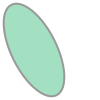

In [151]:
ellipse(gpd.GeoSeries.from_xy(*points.T))

In [152]:
tan_theta(points - points.mean(axis=0))

(np.float64(18.0), np.float64(42.0), np.float64(-16.0), np.float64(-0.5))

In [153]:

    >>> coords = np.array(
    ...     [
    ...         [66.22, 32.54],
    ...         [22.52, 22.39],
    ...         [31.01, 81.21],
    ...         [9.47, 31.02],
    ...         [30.78, 60.10],
    ...         [75.21, 58.93],
    ...         [79.26, 7.68],
    ...         [8.23, 39.93],
    ...         [98.73, 77.17],
    ...         [89.78, 42.53],
    ...         [65.19, 92.08],
                [54.46, 8.48]
    ...     ]
    ... )


In [154]:
coords

array([[66.22, 32.54],
       [22.52, 22.39],
       [31.01, 81.21],
       [ 9.47, 31.02],
       [30.78, 60.1 ],
       [75.21, 58.93],
       [79.26,  7.68],
       [ 8.23, 39.93],
       [98.73, 77.17],
       [89.78, 42.53],
       [65.19, 92.08],
       [54.46,  8.48]])

In [155]:
ellipse(coords)

(np.float64(25.57709673943233),
 np.float64(30.948652369575495),
 np.float64(-1.1039268428650906))

In [156]:
geoms = gpd.GeoSeries.from_xy(*coords.T)

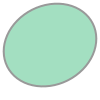

In [157]:
ellipse(geoms)

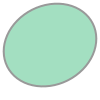

In [158]:
ellipse(geoms)

In [159]:
minimum_rotated_rectangle(coords)

array([[ 75.5990843 ,  -0.72615725],
       [  4.08727852,  30.41752523],
       [ 36.40164577, 104.61744544],
       [107.91345156,  73.47376296]])

In [160]:
minimum_rotated_rectangle(coords, return_angle=True)

(array([[ 75.5990843 ,  -0.72615725],
        [  4.08727852,  30.41752523],
        [ 36.40164577, 104.61744544],
        [107.91345156,  73.47376296]]),
 66.466678613503)

In [161]:
def tan_theta(centered_points):
    x2, y2 = (centered_points * centered_points).sum(axis=0)
    xy = (centered_points[:,0] * centered_points[:,1]).sum()
    d2 = x2 - y2
    ta = d2 + np.sqrt(d2 * d2 + 4 * xy * xy)
    ta /= 2*xy
    t = np.arctan(ta)
    ts = np.arctan(np.abs(ta))
   
    return x2, y2, xy, ta, t, ts

In [162]:
tan_theta(points - points.mean(axis=0))

(np.float64(18.0),
 np.float64(42.0),
 np.float64(-16.0),
 np.float64(-0.5),
 np.float64(-0.4636476090008061),
 np.float64(0.4636476090008061))

In [163]:
np.arctan(.5)

np.float64(0.4636476090008061)

In [164]:
x = np.arange(-10, 11)
y1 = .8 * x

In [165]:
y1

array([-8. , -7.2, -6.4, -5.6, -4.8, -4. , -3.2, -2.4, -1.6, -0.8,  0. ,
        0.8,  1.6,  2.4,  3.2,  4. ,  4.8,  5.6,  6.4,  7.2,  8. ])

In [166]:
y2 = -.8 * x
y2

array([ 8. ,  7.2,  6.4,  5.6,  4.8,  4. ,  3.2,  2.4,  1.6,  0.8, -0. ,
       -0.8, -1.6, -2.4, -3.2, -4. , -4.8, -5.6, -6.4, -7.2, -8. ])

In [167]:
import pandas as pd

In [168]:
df = pd.DataFrame(np.array([x, y1, y2]).T, columns=['x', 'y1', 'y2'])

In [169]:
df.head()

,x,y1,y2
0,-10.0,-8.0,8.0
1,-9.0,-7.2,7.2
2,-8.0,-6.4,6.4
3,-7.0,-5.6,5.6
4,-6.0,-4.8,4.8


<Axes: xlabel='x'>

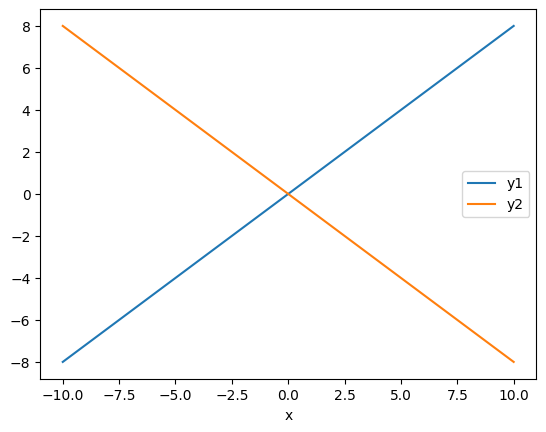

In [170]:
df.plot(x='x', y=['y1', 'y2']) #plots both y1 and y2 against x

In [171]:
np.arctan(-.8)

np.float64(-0.6747409422235527)

In [172]:
np.arctan(.8)

np.float64(0.6747409422235527)

In [173]:
np.degrees(np.arctan(-.8))

np.float64(-38.659808254090095)

In [174]:
np.degrees(np.arctan(.8))

np.float64(38.659808254090095)

In [175]:
np.arctan2(8, -10)

np.float64(2.4668517113662407)

In [176]:
np.arctan2(8, 10)

np.float64(0.6747409422235526)

In [177]:
np.degrees(2.46685)

np.float64(141.34009369184713)

In [178]:
np.arctan2(-8, 10)

np.float64(-0.6747409422235526)

In [179]:
np.degrees(0.78539816)

np.float64(44.99999980534055)

In [180]:
radians = [ 0.78539816,  2.35619449, -2.35619449, -0.78539816]
np.degrees(radians)

array([  44.99999981,  134.99999999, -134.99999999,  -44.99999981])

In [181]:
coordinates = np.array([[1, 1], [-1, 1], [-1, -1], [1, -1]])

In [182]:
radians = np.arctan2(coordinates[:,1], coordinates[:,0])
radians

array([ 0.78539816,  2.35619449, -2.35619449, -0.78539816])

## Qgis

In [183]:
import geopandas as gpd

In [184]:
gdf = gpd.read_file("~/para/1_projects/6029qgis-ellipse/qgisstandarddeviationalellipseplugin/data/points.shp")

<Axes: >

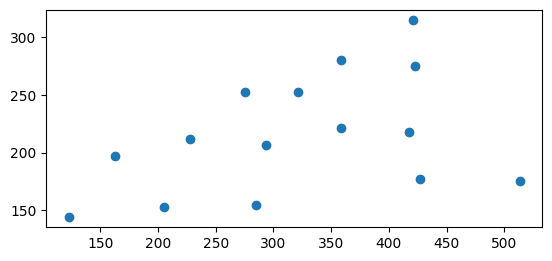

In [185]:
gdf.plot()

In [186]:
gdf.head()

,X,Y,w,geometry
0,122.719424,143.956835,1,POINT (122.719 143.957)
1,227.697842,212.100719,3,POINT (227.698 212.101)
2,284.791367,155.007194,1,POINT (284.791 155.007)
3,294.000000,206.575540,2,POINT (294 206.576)
4,358.460432,221.309353,1,POINT (358.46 221.309)


In [187]:
wegdf = gpd.read_file("~/para/1_projects/6029qgis-ellipse/testing/weighted_ellipse.gpkg")

<Axes: >

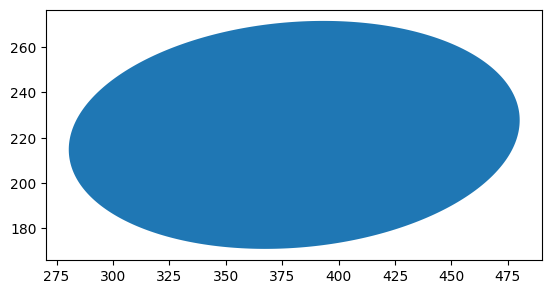

In [188]:
wegdf.plot()

In [189]:
egdf = gpd.read_file("~/para/1_projects/6029qgis-ellipse/testing/ellipse.gpkg")

<Axes: >

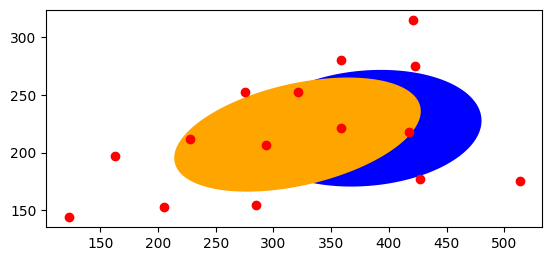

In [190]:
base = wegdf.plot(color='blue')
egdf.plot(ax = base, color='orange')
gdf.plot(ax=base, color='red')

# PySAL

In [191]:
from pointpats.centrography import ellipse

In [192]:
epysal = ellipse(gdf)

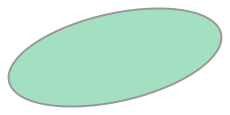

In [193]:
epysal

In [194]:
epysal = gpd.GeoSeries([epysal])

In [195]:
epysal.centroid, epysal.area

(0    POINT (320.889 215.661)
 dtype: geometry,
 0    15090.266218
 dtype: float64)

<Axes: >

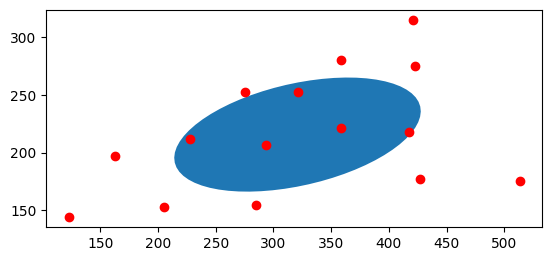

In [196]:
base = epysal.plot()
#egdf.plot(ax=base, color='orange')
gdf.plot(ax=base, color='r')

In [197]:
egdf.area, egdf.centroid

(0    15113.766872
 dtype: float64,
 0    POINT (320.889 215.661)
 dtype: geometry)

In [198]:
ellipse(points)

(np.float64(2.6726124191242437),
 np.float64(1.1952286093343936),
 np.float64(-1.1071487177940904))

In [199]:
np.degrees(0.553574)

np.float64(31.717453848175033)

In [200]:
np.degrees(1.107148)

np.float64(63.434907696350066)

In [201]:
pps = np.array(
    [
        [66.22, 32.54],
        [22.52, 22.39],
        [31.01, 81.21],
        [9.47, 31.02],
        [30.78, 60.10],
        [75.21, 58.93],
        [79.26, 7.68],
        [8.23, 39.93],
        [98.73, 77.17],
        [89.78, 42.53],
        [65.19, 92.08],
        [54.46, 8.48],
    ]
)

In [202]:
ellipse(pps)

(np.float64(25.57709673943233),
 np.float64(30.948652369575495),
 np.float64(-1.1039268428650906))

In [203]:
import geopandas as gpd
geoms = gpd.GeoSeries.from_xy(*pps.T)

In [204]:
np.degrees(0.55357)

np.float64(31.717224665056982)

# Data from Lefever 1926

In [205]:
points = [
    (5, 15),
    (17, 17),
    (20, 8),
    (25, 0),
    (17, -6),
    (8, -11),
    (5, -4),
    (-2, -7),
    (-11, -2),
    (-12, 9)
]

In [206]:
def is_inside_ellipse(points, center, major_axis, minor_axis, angle):
    """
    Check if a set of points are inside an ellipse.
    
    Parameters:
    points (array-like): List of (x, y) points to check.
    center (tuple): (x, y) coordinates of the ellipse center.
    major_axis (float): Length of the major axis.
    minor_axis (float): Length of the minor axis.
    angle (float): Rotation angle of the ellipse in radians.
    
    Returns:
    numpy array: Boolean array indicating whether each point is inside the ellipse.
    """
    # Convert inputs to numpy arrays
    points = np.asarray(points)
    center = np.asarray(center)
    
    # Translate points to the ellipse's coordinate system
    translated_points = points - center
    
    # Rotation matrix to align with the ellipse's axes
    cos_a, sin_a = np.cos(-angle), np.sin(-angle)
    rotation_matrix = np.array([[cos_a, -sin_a], [sin_a, cos_a]])
    
    # Rotate points to align with the ellipse axes
    rotated_points = np.dot(translated_points, rotation_matrix.T)
    
    # Check the ellipse equation: (x/a)^2 + (y/b)^2 <= 1
    x, y = rotated_points[:, 0], rotated_points[:, 1]
    ellipse_eq = (x / (major_axis / 2))**2 + (y / (minor_axis / 2))**2
    
    return ellipse_eq <= 1


In [207]:
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse
from pylab import figure, show,rand

def plot_ellipse(mc, width, height, angle):
    
    fig = figure()
    
    ax = fig.add_subplot(111, aspect='equal')
    e = Ellipse(xy=mc, width=width, height=height, angle=angle) #angle is rotation in degrees (anti-clockwise)
    #ax = pp.plot(get_ax=True, title='Standard Deviational Ellipse')
    ax.add_patch(e)
    ax.add_artist(e)
    e.set_clip_box(ax.bbox)
    e.set_facecolor([0.8,0,0])
    e.set_edgecolor([1,0,0])
    #ax.set_xlim(0,100)
    #ax.set_ylim(0,100)
    ax.set_aspect('equal')
  
    plt.plot(mc[0], mc[1], 'b^', label='Mean Center')
    plt.legend(numpoints=1)
    show()

## Numpy

In [208]:
import numpy
def np_ellipse(points):

    # Compute the centroid
    centroid = np.mean(points, axis=0)
    
    # Center the points
    centered_points = points - centroid
    
    # Compute the covariance matrix
    cov_matrix = np.cov(centered_points, rowvar=False)
    
    # Eigen decomposition of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues and eigenvectors
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    # Major and minor axis lengths (2 * sqrt(eigenvalues) for full length)
    major_axis_length = 2 * np.sqrt(eigenvalues[0])
    minor_axis_length = 2 * np.sqrt(eigenvalues[1])
    
    # Angle of rotation (in degrees)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    
    # Print results
    print(f"Centroid: {centroid}")
    print(f"Major Axis Length: {major_axis_length}")
    print(f"Minor Axis Length: {minor_axis_length}")
    print(f"Angle of Rotation: {angle} degrees")
    result = {}
    result['major_axis_length'] = major_axis_length
    result['minor_axis_length'] = minor_axis_length
    result['angle'] = angle
    result['center'] = centroid
    return result

In [209]:
np_ellipse(points)

Centroid: [7.2 1.9]
Major Axis Length: 25.690450597247164
Minor Axis Length: 19.223847264945647
Angle of Rotation: -170.60924020040648 degrees


{'major_axis_length': np.float64(25.690450597247164),
 'minor_axis_length': np.float64(19.223847264945647),
 'angle': np.float64(-170.60924020040648),
 'center': array([7.2, 1.9])}

In [210]:
res = np_ellipse(points)

Centroid: [7.2 1.9]
Major Axis Length: 25.690450597247164
Minor Axis Length: 19.223847264945647
Angle of Rotation: -170.60924020040648 degrees


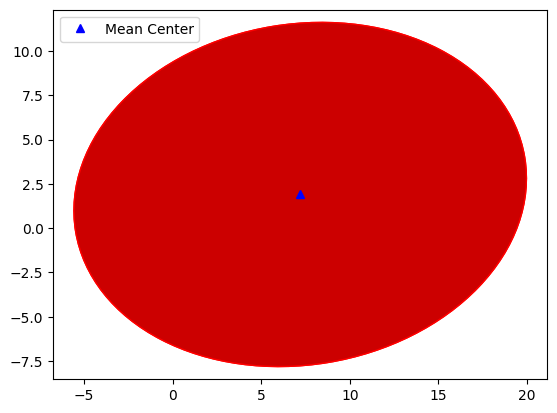

In [211]:
plot_ellipse(res['center'], res['major_axis_length'],
             res['minor_axis_length'], res['angle'])


In [212]:
is_inside_ellipse([[-5, -7.5], [10,2.5]],
                  res['center'],
                  res['major_axis_length'],
                  res['minor_axis_length'],
                  res['angle'])

array([False,  True])

In [213]:
is_inside_ellipse(points,
                  res['center'],
                  res['major_axis_length'],
                  res['minor_axis_length'],
                  res['angle'])

array([False, False, False, False, False, False,  True, False, False,
       False])

In [214]:
points

[(5, 15),
 (17, 17),
 (20, 8),
 (25, 0),
 (17, -6),
 (8, -11),
 (5, -4),
 (-2, -7),
 (-11, -2),
 (-12, 9)]

## Gong 2002

In [215]:
def sde(x, y):
    xm = x.mean()
    ym = y.mean()
    x0 = x - xm
    y0 = y - ym
    sig_x = (x0*x0).mean()**(.5)
    sig_y = (y0*y0).mean()**(.5)

In [216]:
lp = PointPattern(np.array(points))

In [217]:
lp

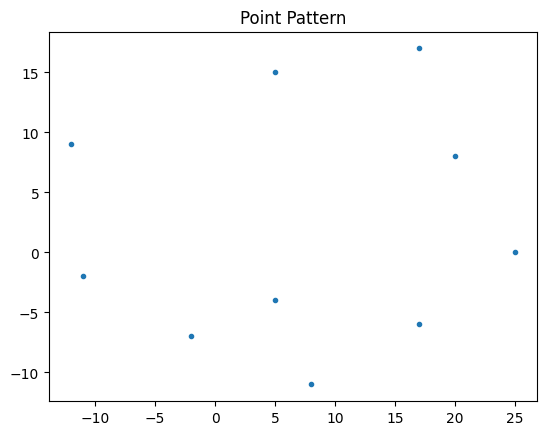

In [218]:
lp.plot()

In [219]:
mc = mean_center(lp.points)

In [220]:
lp.points.mean()

x    7.2
y    1.9
dtype: float64

In [221]:
mean_center?

Signature: mean_center(points)
Docstring:
Find mean center of a point array.

Parameters
----------
points : arraylike
         array representing a point pattern

Returns
-------
center
    center of a given point pattern

Examples
--------
>>> import numpy as np
>>> import geopandas as gpd

Create an array of point coordinates.

>>> coords = np.array(
...     [
...         [66.22, 32.54],
...         [22.52, 22.39],
...         [31.01, 81.21],
...         [9.47, 31.02],
...         [30.78, 60.10],
...         [75.21, 58.93],
...         [79.26, 7.68],
...         [8.23, 39.93],
...         [98.73, 77.17],
...         [89.78, 42.53],
...         [65.19, 92.08],
...         [54.46, 8.48],
...     ]
... )

Passing an array of coordinates returns an array capturing the center.

>>> mean_center(coords)
array([52.57166667, 46.17166667])

Passing a GeoPandas object returns a shapely geometry.

>>> geoms = gpd.GeoSeries.from_xy(*coords.T)
>>> mean_center(geoms)
<POINT (52.572 46.172)>
File: 

In [222]:
lp

In [223]:
mean_center(lp.points)

array([7.2, 1.9])

In [224]:
(lp.points.x * lp.points.y).sum() - 10*7.2*1.9

np.float64(105.20000000000002)

In [225]:
(lp.points.x**2).sum(), (lp.points.y**2).sum()

(np.int64(1986), np.int64(885))

In [226]:
A = 1986 - 885
A

1101

In [227]:
np.degrees(0.16535)

np.float64(9.473857142488162)

In [228]:
np.degrees(-6.04653)

np.float64(-346.44064969923767)

In [229]:
np.arctan(0.16535)

np.float64(0.16386732344828042)

In [230]:
np.arctan?

Signature:       np.arctan(*args, **kwargs)
Type:            ufunc
String form:     <ufunc 'arctan'>
File:            ~/miniforge3/envs/pointpats/lib/python3.12/site-packages/numpy/__init__.py
Docstring:      
arctan(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

Trigonometric inverse tangent, element-wise.

The inverse of tan, so that if ``y = tan(x)`` then ``x = arctan(y)``.

Parameters
----------
x : array_like
out : ndarray, None, or tuple of ndarray and None, optional
    A location into which the result is stored. If provided, it must have
    a shape that the inputs broadcast to. If not provided or None,
    a freshly-allocated array is returned. A tuple (possible only as a
    keyword argument) must have length equal to the number of outputs.
where : array_like, optional
    This condition is broadcast over the input. At locations where the
    condition is True, the `out` array will be set to the ufunc result.
    Elsewhere

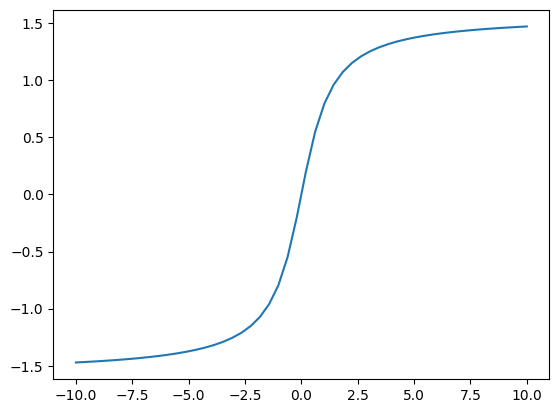

In [231]:
>>> import matplotlib.pyplot as plt
>>> x = np.linspace(-10, 10)
>>> plt.plot(x, np.arctan(x))
>>> plt.axis('tight')
>>> plt.show()

In [232]:
import numpy as np
import pandas as pd

def sde(id=1, centre_xy=None, calccentre=True, weighted=False, weights=None, points=None, verbose=False):
    """
    Standard Deviation Ellipse 
    
    Parameters:
    - id: Unique identifier for the SDE
    - centre_xy: Tuple (x, y) for the center; if None, it will be computed
    - calccentre: Boolean, if True, computes the center from points
    - weighted: Boolean, if True, uses weights for center computation
    - weights: Array of weights (same length as points)
    - points: Numpy array or list of shape (n, 2) containing x, y coordinates
    - verbose: Boolean, if True, prints results
    
    Returns:
    - Dictionary containing SDE parameters and ellipse coordinates
    """
    
    # Error checking
    if points is None or len(points) == 0:
        raise ValueError("Points array cannot be empty.")
    points = np.asarray(points)
    
    if points.shape[1] != 2:
        raise ValueError("Points should have exactly 2 columns (x, y).")
    
    n = points.shape[0]
    
    if calccentre:
        if centre_xy is not None:
            raise ValueError("Invalid combination: calccentre=True and centre_xy!=None")
        if weighted and weights is not None:
            weights = np.asarray(weights)
            WMC_x = np.sum(points[:, 0] * weights) / np.sum(weights)
            WMC_y = np.sum(points[:, 1] * weights) / np.sum(weights)
            centre_xy = np.array([WMC_x, WMC_y])
        else:
            centre_xy = np.mean(points, axis=0)
    
    # Compute deviations
    x_prime = points[:, 0] - centre_xy[0]
    y_prime = points[:, 1] - centre_xy[1]

    # Compute moments
    x_prime2 = x_prime ** 2
    y_prime2 = y_prime ** 2
    xy_prime = x_prime * y_prime

    if weighted and weights is not None:
        Sxx = np.sum(weights * x_prime2) / np.sum(weights)
        Syy = np.sum(weights * y_prime2) / np.sum(weights)
        Sxy = np.sum(weights * xy_prime) / np.sum(weights)
    else:
        Sxx = np.sum(x_prime2) / (n - 1)
        Syy = np.sum(y_prime2) / (n - 1)
        Sxy = np.sum(xy_prime) / (n - 1)

    # Compute rotation angle theta
    top1 = Sxx - Syy
    top2 = np.sqrt((Sxx - Syy) ** 2 + 4 * Sxy ** 2)
    bottom = 2 * Sxy
    tantheta = (top1 + top2) / bottom
    theta = np.arctan(tantheta) * (180 / np.pi)  # Convert radians to degrees

    # Compute standard deviations (ellipse axes)
    lambda1 = (Sxx + Syy) / 2 + np.sqrt(((Sxx - Syy) / 2) ** 2 + Sxy ** 2)
    lambda2 = (Sxx + Syy) / 2 - np.sqrt(((Sxx - Syy) / 2) ** 2 + Sxy ** 2)
    
    sigma_x = np.sqrt(lambda1)
    sigma_y = np.sqrt(lambda2)

    # Identify major and minor axis
    if sigma_x > sigma_y:
        Major, Minor = "SigmaX", "SigmaY"
    else:
        Major, Minor = "SigmaY", "SigmaX"

    # Compute other ellipse properties
    area_sde = np.pi * sigma_x * sigma_y
    eccentricity = np.sqrt(1 - (min(sigma_x, sigma_y) ** 2) / (max(sigma_x, sigma_y) ** 2))

    # Generate ellipse coordinates
    angles = np.linspace(0, 2 * np.pi, 360)
    ellipse_x = sigma_x * np.cos(angles)
    ellipse_y = sigma_y * np.sin(angles)

    # Rotate ellipse to match orientation
    theta_rad = np.radians(90 - theta)
    cos_t, sin_t = np.cos(theta_rad), np.sin(theta_rad)
    rotated_x = cos_t * ellipse_x - sin_t * ellipse_y + centre_xy[0]
    rotated_y = sin_t * ellipse_x + cos_t * ellipse_y + centre_xy[1]
    
    coords_sde = np.column_stack((rotated_x, rotated_y))

    if verbose:
        print(f"\nStandard Deviation Ellipse (SDE) Results:")
        print(f"Centre (x, y): {centre_xy}")
        print(f"Rotation angle: {theta:.2f}°")
        print(f"Major axis: {Major}, Minor axis: {Minor}")
        print(f"Length of major axis: {2 * sigma_x:.2f}")
        print(f"Length of minor axis: {2 * sigma_y:.2f}")
        print(f"Area: {area_sde:.2f}")
        print(f"Eccentricity: {eccentricity:.4f}\n")

    # Store results in a dictionary
    result = {
        "id": id,
        "centre_x": centre_xy[0],
        "centre_y": centre_xy[1],
        "major_axis": Major,
        "minor_axis": Minor,
        "theta": theta,
        "sigma_x": sigma_x,
        "sigma_y": sigma_y,
        "area": area_sde,
        "eccentricity": eccentricity,
        "coords_sde": coords_sde,
    }

    return result


In [233]:
res = sde(points=points)

In [234]:
res['theta']

np.float64(80.60924020040645)

In [235]:
90-80.6

9.400000000000006

In [236]:
res['area']

np.float64(387.8840399603182)

## SDC

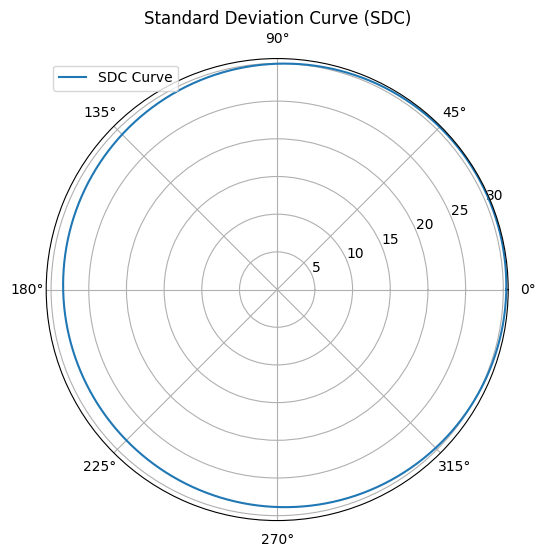

Circularity Index: 0.9251


In [237]:
import numpy as np
import matplotlib.pyplot as plt

def compute_sdc(points, num_angles=360):
    """
    Compute the Standard Deviation Curve (SDC) for a set of points.

    Parameters:
    - points: np.array of shape (n, 2) representing x, y coordinates.
    - num_angles: Number of angles to rotate for computing SDC.

    Returns:
    - angles: Array of angles in degrees.
    - sdc_values: Standard deviation values at each angle.
    - circularity_index: Ratio of min to max standard deviation.
    """
    # Compute mean center
    centroid = np.mean(points, axis=0)
    
    # Center the points
    centered_points = points - centroid
    
    # Initialize storage for standard deviations
    angles = np.linspace(0, np.pi, num_angles)  # From 0 to 180 degrees
    sdc_values = np.zeros(num_angles)
    cor_values = np.zeros(num_angles)

    # Compute standard deviation for each rotated system
    for i, theta in enumerate(angles):
        # Rotation matrix
        R = np.array([[np.cos(theta), -np.sin(theta)],
                      [np.sin(theta), np.cos(theta)]])
        
        # Rotate points
        rotated_points = centered_points @ R.T
        
        
        # Standard deviation along the x-axis (first column after rotation)
        sdc_values[i] = np.std(rotated_points[:, 0])

    # Find max and min standard deviation
    sigma_max = np.max(sdc_values)
    sigma_min = np.min(sdc_values)
    
    # Compute circularity index
    circularity_index = sigma_min / sigma_max if sigma_max > 0 else 0
    
    # Plot SDC
    plt.figure(figsize=(6,6))
    plt.polar(angles * 2, sdc_values, label="SDC Curve")
    plt.title("Standard Deviation Curve (SDC)")
    plt.legend()
    plt.show()

    return angles, sdc_values, circularity_index
# Example usage with random points
np.random.seed(42)
points = np.random.rand(100, 2) * 100  # 100 random points in a 100x100 space
angles, sdc_values, circularity_index = compute_sdc(points)

print(f"Circularity Index: {circularity_index:.4f}")


In [238]:
points = [
    (5, 15),
    (17, 17),
    (20, 8),
    (25, 0),
    (17, -6),
    (8, -11),
    (5, -4),
    (-2, -7),
    (-11, -2),
    (-12, 9)
]

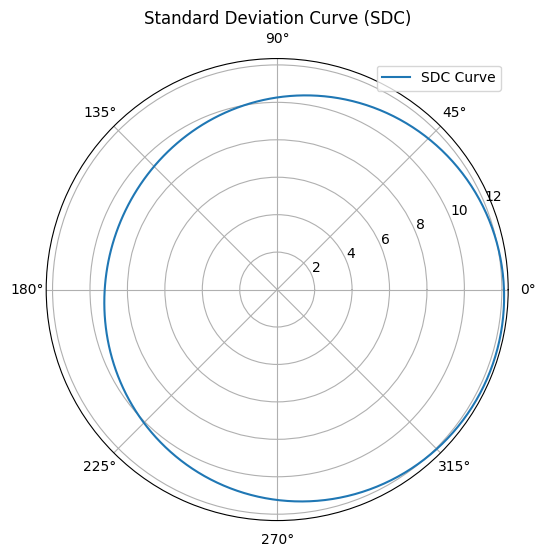

In [239]:
a,b,c =compute_sdc(points)

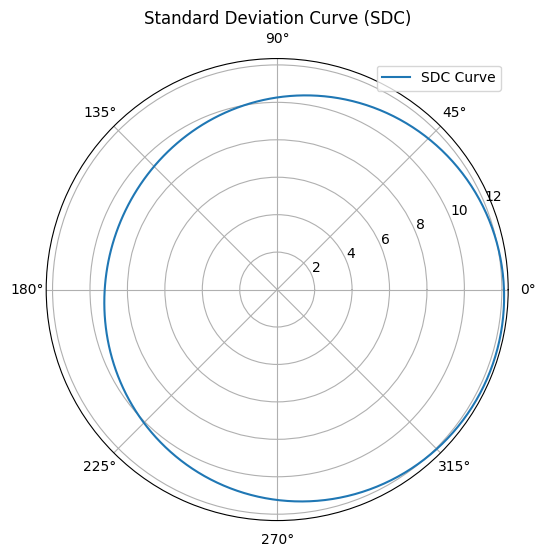

In [240]:
a,b,c =compute_sdc(points)

In [241]:
points = [
    [2,2],
    [3,3],
    [4,4],
    [-2, -3],
    [-8, -7]
]

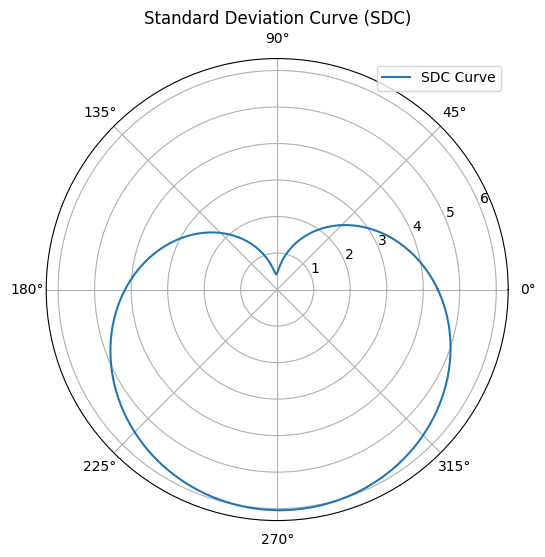

In [242]:
a,b,c =compute_sdc(points)

In [243]:
a[0:5]

array([0.        , 0.00875095, 0.01750191, 0.02625286, 0.03500382])

In [244]:
b[0:5]

array([4.4       , 4.36371727, 4.32710618, 4.29016969, 4.25291077])

In [245]:
a[-1]

np.float64(3.141592653589793)

In [246]:
np.degrees(a)

array([  0.        ,   0.50139276,   1.00278552,   1.50417827,
         2.00557103,   2.50696379,   3.00835655,   3.5097493 ,
         4.01114206,   4.51253482,   5.01392758,   5.51532033,
         6.01671309,   6.51810585,   7.01949861,   7.52089136,
         8.02228412,   8.52367688,   9.02506964,   9.5264624 ,
        10.02785515,  10.52924791,  11.03064067,  11.53203343,
        12.03342618,  12.53481894,  13.0362117 ,  13.53760446,
        14.03899721,  14.54038997,  15.04178273,  15.54317549,
        16.04456825,  16.545961  ,  17.04735376,  17.54874652,
        18.05013928,  18.55153203,  19.05292479,  19.55431755,
        20.05571031,  20.55710306,  21.05849582,  21.55988858,
        22.06128134,  22.56267409,  23.06406685,  23.56545961,
        24.06685237,  24.56824513,  25.06963788,  25.57103064,
        26.0724234 ,  26.57381616,  27.07520891,  27.57660167,
        28.07799443,  28.57938719,  29.08077994,  29.5821727 ,
        30.08356546,  30.58495822,  31.08635097,  31.58

In [247]:
c

np.float64(0.06870572062756841)

In [248]:
import numpy as np

def compute_sdc_pca(points):
    """
    Compute the maximum and minimum standard deviations (major & minor axes)
    using PCA (Eigenvalue decomposition of the covariance matrix).
    
    Parameters:
    - points: np.array of shape (n, 2), representing x, y coordinates.
    
    Returns:
    - max_std: Standard deviation along the major axis.
    - min_std: Standard deviation along the minor axis.
    - major_axis_angle: Orientation of the major axis in degrees.
    """
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid

    # Compute covariance matrix
    cov_matrix = np.cov(centered_points, rowvar=False)

    # Perform Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort eigenvalues in descending order (largest variance first)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Standard deviations are sqrt of eigenvalues
    max_std = np.sqrt(eigenvalues[0])  # Major axis std deviation
    min_std = np.sqrt(eigenvalues[1])  # Minor axis std deviation

    # Compute the angle of the major axis
    major_axis_angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    return max_std, min_std, major_axis_angle

# Example usage
np.random.seed(42)
points = np.random.rand(100, 2) * 100  # Generate random points

max_std, min_std, major_axis_angle = compute_sdc_pca(points)

print(f"Max standard deviation: {max_std:.4f}")
print(f"Min standard deviation: {min_std:.4f}")
print(f"Major axis orientation: {major_axis_angle:.2f} degrees")


Max standard deviation: 30.6883
Min standard deviation: 28.3911
Major axis orientation: 165.48 degrees


In [249]:
import numpy as np

def compute_sdc_pca(points):
    """
    Compute the maximum and minimum standard deviations (major & minor axes)
    using PCA (Eigenvalue decomposition of the covariance matrix).
    
    Parameters:
    - points: np.array of shape (n, 2), representing x, y coordinates.
    
    Returns:
    - max_std: Standard deviation along the major axis.
    - min_std: Standard deviation along the minor axis.
    - major_axis_angle: Orientation of the major axis in degrees.
    """
    # Center the points
    centroid = np.mean(points, axis=0)
    centered_points = points - centroid

    # Compute covariance matrix
    cov_matrix = np.cov(centered_points, rowvar=False)

    # Perform Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort eigenvalues in descending order (largest variance first)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Standard deviations are sqrt of eigenvalues
    max_std = np.sqrt(eigenvalues[0])  # Major axis std deviation
    min_std = np.sqrt(eigenvalues[1])  # Minor axis std deviation

    # Compute the angle of the major axis
    major_axis_angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    return max_std, min_std, major_axis_angle

# Example usage
np.random.seed(42)
points = np.random.rand(100, 2) * 100  # Generate random points

max_std, min_std, major_axis_angle = compute_sdc_pca(points)

print(f"Max standard deviation: {max_std:.4f}")
print(f"Min standard deviation: {min_std:.4f}")
print(f"Major axis orientation: {major_axis_angle:.2f} degrees")


Max standard deviation: 30.6883
Min standard deviation: 28.3911
Major axis orientation: 165.48 degrees


In [250]:
points = [
    (5, 15),
    (17, 17),
    (20, 8),
    (25, 0),
    (17, -6),
    (8, -11),
    (5, -4),
    (-2, -7),
    (-11, -2),
    (-12, 9)
]

max_std, min_std, major_axis_angle = compute_sdc_pca(points)

print(f"Max standard deviation: {max_std:.4f}")
print(f"Min standard deviation: {min_std:.4f}")
print(f"Major axis orientation: {major_axis_angle:.2f} degrees")


Max standard deviation: 12.8452
Min standard deviation: 9.6119
Major axis orientation: -170.61 degrees


# QGIS Replication


## Test Points

<Axes: >

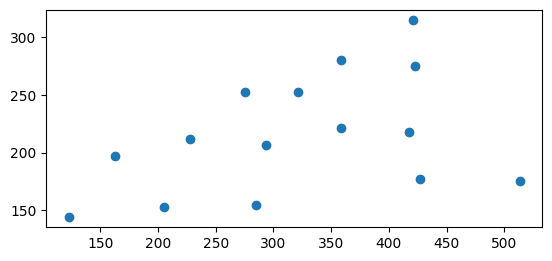

In [251]:
qpoints = gpd.read_file('qgis_points.shp')
qpoints.plot()

## Default Ellipse

In [252]:
qe = gpd.read_file('sde_yuill_ellipse_default.shp')

<Axes: >

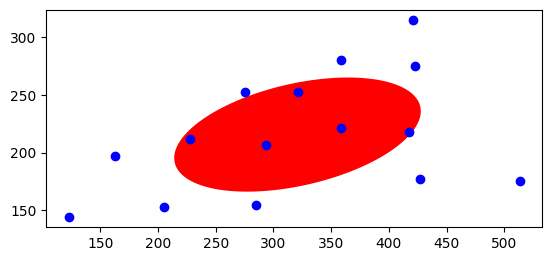

In [253]:
base = qe.plot(color='red')
qpoints.plot(ax=base, color='blue')

## PySAL replicating default ellipse

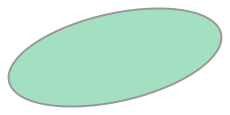

In [254]:
pe = ellipse(qpoints)
pe

<Axes: >

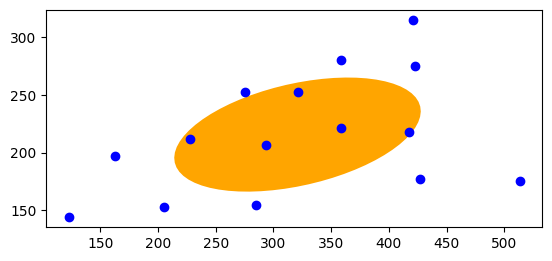

In [255]:
pedf = gpd.GeoDataFrame(geometry=[pe])
base = pedf.plot(color='orange')
qpoints.plot(ax=base, color='blue')

In [256]:
qe.area

0    15113.766872
dtype: float64

In [257]:
pe.area

15090.266217724058

## Adding weighted option

In [258]:
def ellipse_w(points, weight_column=None):
    x = points.geometry.x
    y = points.geometry.y
    if weight_column:
        w = points[weight_column]
    else:
        w = np.ones(x.shape[0])
   
    sumx = (x * w).sum()
    sumy = (y * w).sum()
    sumw = w.sum()
    meanx = sumx / sumw
    meany = sumy / sumw

    xm = x - meanx
    ym = y - meany
    xyw = (xm * ym * w).sum()
    x2w = (xm * xm * w).sum()
    y2w = (ym * ym * w).sum()

    # angle
    den = 2 * xyw
    left = x2w - y2w
    right = np.sqrt( (x2w - y2w)**2 + 4 * xyw * xyw)
    num1 = left + right
    tantheta1 = - num1 / den
    num2 = left - right
    tantheta2 = - num2 / den
    theta1 = np.arctan(tantheta1) # clockwise rotation of y-axix
    theta2 = np.arctan(tantheta2) 
    
    

    # semi-major/minor axis length

    term1 = (w * (ym * np.cos(theta1) - xm * np.sin(theta1))**2).sum()
    term2 = (w * (ym * np.cos(theta2) - xm * np.sin(theta2))**2).sum()

    sx = np.sqrt(term1 / sumw)
    sy = np.sqrt(term2 / sumw)
                  

    return sx, sy, theta1, meanx, meany
    

In [259]:

def ellipse_w(points, weight_column=None, method="crimestat", 
              crimestatCorr=True, degfreedCorr=True):
    """
    Computes a weighted standard deviational ellipse for a set of point geometries.

    Parameters:
        points (GeoDataFrame): GeoPandas object with Point geometries.
        weight_column (str, optional): Name of the column with weights.
        method (str): Correction method to apply. Must be 'crimestat' or 'yuill'.
        crimestatCorr (bool): Apply CrimeStat correction if method == 'yuill'.
        degfreedCorr (bool): Apply degrees-of-freedom correction if method == 'yuill'.

    Returns:
        tuple: (major_axis_length, minor_axis_length, rotation_angle)
    """
    if method not in ("crimestat", "yuill"):
        raise ValueError("`method` must be either 'crimestat' or 'yuill'")

    # Extract coordinates
    x = points.geometry.x
    y = points.geometry.y

    # Set weights
    if weight_column:
        w = points[weight_column].to_numpy()
    else:
        w = np.ones(len(points))

    # Weighted means
    sumw = w.sum()
    meanx = np.average(x, weights=w)
    meany = np.average(y, weights=w)

    # Centered coordinates
    xm = x - meanx
    ym = y - meany

    # Weighted second moments
    xyw = np.sum(xm * ym * w)
    x2w = np.sum(xm**2 * w)
    y2w = np.sum(ym**2 * w)

    # Rotation angles (theta1, theta2)
    den = 2 * xyw
    left = x2w - y2w
    right = np.sqrt(left**2 + 4 * xyw**2)
    
    if den == 0:
        theta1 = 0
        theta2 = np.pi / 2
    else:
        theta1 = np.arctan(-(left + right) / den)
        theta2 = np.arctan(-(left - right) / den)

    # Axis lengths
    term1 = np.sum(w * (ym * np.cos(theta1) - xm * np.sin(theta1))**2)
    term2 = np.sum(w * (ym * np.cos(theta2) - xm * np.sin(theta2))**2)

    sx = np.sqrt(term1 / sumw)
    sy = np.sqrt(term2 / sumw)

    # Corrections
    n = len(points)
    if method == "crimestat":
        correction = (np.sqrt(2) * np.sqrt(n)) / np.sqrt(n - 2)
        sx *= correction
        sy *= correction
    elif method == "yuill":
        if crimestatCorr:
            sx *= np.sqrt(2)
            sy *= np.sqrt(2)
        if degfreedCorr:
            sx *= np.sqrt(n) / np.sqrt(n - 2)
            sy *= np.sqrt(n) / np.sqrt(n - 2)

    # Assign major/minor axis and corresponding angle
    if sy > sx:
        major_axis, minor_axis = sy, sx
        major_angle, minor_angle = theta1, theta2
    else:
        major_axis, minor_axis = sx, sy
        major_angle, minor_angle = theta2, theta1

    return major_axis, minor_axis, major_angle



In [260]:
ellipse_w(qpoints, 'w')

(np.float64(152.21282509078293),
 np.float64(75.88153063710277),
 np.float64(0.0867678036917822))

In [261]:
ellipse_w(qpoints) # unweighted

(np.float64(165.6330503042113),
 np.float64(67.03101536116837),
 np.float64(0.22481321936512555))

<Axes: >

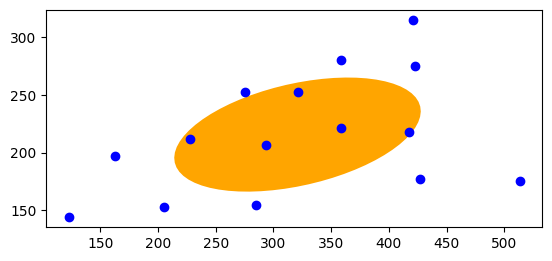

In [262]:
pedf = gpd.GeoDataFrame(geometry=[pe])
base = pedf.plot(color='orange')
qpoints.plot(ax=base, color='blue')

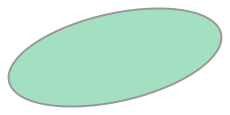

In [263]:
coords = shapely.get_coordinates(qpoints.geometry)
major, minor, rotation = ellipse(coords)

c = shapely.geometry.Point(coords.mean(axis=0))
centre = c.buffer(1)
scaled = shapely.affinity.scale(centre, major, minor)
rotated = shapely.affinity.rotate(scaled, rotation, use_radians=True)
rotated

<Axes: >

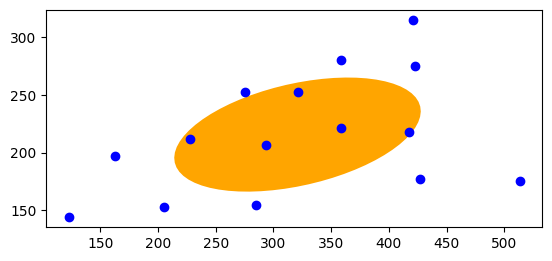

In [264]:
pedf = gpd.GeoDataFrame(geometry=[rotated])
base = pedf.plot(color='orange')
qpoints.plot(ax=base, color='blue')

### We replicate the qgis code for the default  up to here

### Compare options

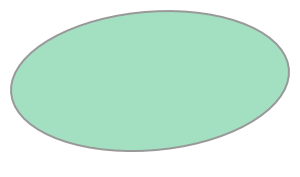

In [265]:
coords = shapely.get_coordinates(qpoints.geometry)
major, minor, rotation = ellipse_w(qpoints, 'w')
meanx, meany = coords.mean(axis=0)
c = shapely.geometry.Point([meanx, meany])
centre = c.buffer(1)
scaled = shapely.affinity.scale(centre, major, minor)
rotated = shapely.affinity.rotate(scaled, rotation, use_radians=True)
rotated

<Axes: >

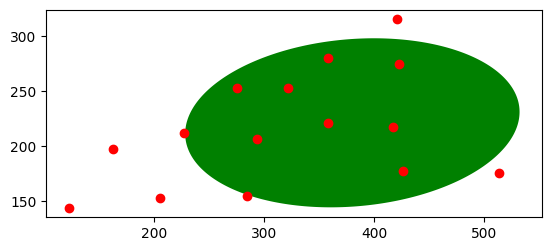

In [266]:
qew = gpd.read_file('sde_yulli_ellipse_w_both_corrections.shp')
base = qew.plot(color='green')
qpoints.plot(ax=base, color='r')

#gpd.GeoSeries([rotated]).plot(ax=base)

<Axes: >

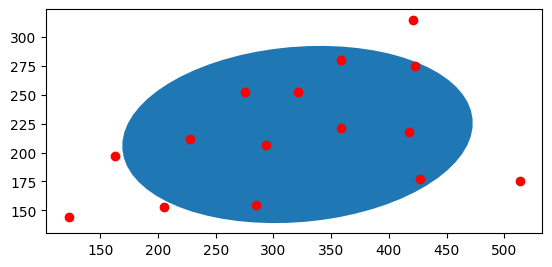

In [267]:
base = gpd.GeoSeries([rotated]).plot()
qpoints.plot(ax=base, color='r')



In [268]:
c.coords.xy

(array('d', [320.8892086330938]), array('d', [215.66139088729093]))

In [269]:
major, minor, rotation

(np.float64(152.21282509078293),
 np.float64(75.88153063710277),
 np.float64(0.0867678036917822))

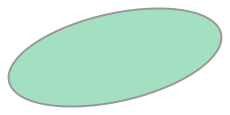

In [270]:
ellipse(qpoints)

In [271]:
np.degrees(1.4850285) + np.degrees(0.08676)

np.float64(90.05684733719839)

In [272]:
from pointpats.centrography import ellipse_w

In [273]:
ellipse_w?

Signature:
ellipse_w(
    points,
    weights=None,
    method='crimestat',
    crimestatCorr=True,
    degfreedCorr=True,
)
Docstring:
Computes a weighted standard deviational ellipse for a set of point geometries.

Parameters:
    points : arraylike
             array representing a point pattern
    weights : arraylike
             array of weights for each point (Optional)
    method (str): Correction method to apply. Must be 'crimestat' or 'yuill'.
    crimestatCorr (bool): Apply CrimeStat correction if method == 'yuill'.
    degfreedCorr (bool): Apply degrees-of-freedom correction if method == 'yuill'.

Returns:
    tuple: (major_axis_length, minor_axis_length, rotation_angle)
File:      ~/para/1_projects/dev-pointpats/pointpats/pointpats/centrography.py
Type:      function

## testing code paths

In [274]:
methods = ['crimestat', 'yuill']
weights = [ None, qpoints.w]
degfreedCorrs = [ True, False]
crimestatCorrs = [ True, False]
results = []
params = []
for method in methods:
    for weight in weights:
        for degfreedCorr in degfreedCorrs:
            for crimestatCorr in crimestatCorrs:
                results.append(ellipse_w(qpoints, weights=weight, method=method,
                                        crimestatCorr=crimestatCorr,
                                        degfreedCorr=degfreedCorr))
                if weight is None:
                    params.append([method, False, degfreedCorr, crimestatCorr])
                else:
                    params.append([method, True, degfreedCorr, crimestatCorr])

>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called ellipse_w for np.array
>>> Called ellipse_w for GeoPandasBase
>>> Called e

In [275]:
methods = ['crimestat', 'yuill']
weights = [ None, qpoints.w]
degfreedCorrs = [ True, False]
crimestatCorrs = [ True, False]
results = []
params = []
points = shapely.get_coordinates(qpoints.geometry)
for method in methods:
    for weight in weights:
        for degfreedCorr in degfreedCorrs:
            for crimestatCorr in crimestatCorrs:
                results.append(ellipse_w(points, weights=weight, method=method,
                                        crimestatCorr=crimestatCorr,
                                        degfreedCorr=degfreedCorr))
                if weight is None:
                    params.append([method, False, degfreedCorr, crimestatCorr])
                else:
                    params.append([method, True, degfreedCorr, crimestatCorr])

>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array
>>> Called ellipse_w for np.array


In [276]:
params

[['crimestat', False, True, True],
 ['crimestat', False, True, False],
 ['crimestat', False, False, True],
 ['crimestat', False, False, False],
 ['crimestat', True, True, True],
 ['crimestat', True, True, False],
 ['crimestat', True, False, True],
 ['crimestat', True, False, False],
 ['yuill', False, True, True],
 ['yuill', False, True, False],
 ['yuill', False, False, True],
 ['yuill', False, False, False],
 ['yuill', True, True, True],
 ['yuill', True, True, False],
 ['yuill', True, False, True],
 ['yuill', True, False, False]]

In [277]:
results

[(np.float64(165.6330503042113),
  np.float64(67.03101536116837),
  np.float64(0.22481321936512555)),
 (np.float64(165.6330503042113),
  np.float64(67.03101536116837),
  np.float64(0.22481321936512555)),
 (np.float64(165.6330503042113),
  np.float64(67.03101536116837),
  np.float64(0.22481321936512555)),
 (np.float64(165.6330503042113),
  np.float64(67.03101536116837),
  np.float64(0.22481321936512555)),
 (np.float64(152.21282509078293),
  np.float64(75.88153063710277),
  np.float64(0.0867678036917822)),
 (np.float64(152.21282509078293),
  np.float64(75.88153063710277),
  np.float64(0.0867678036917822)),
 (np.float64(152.21282509078293),
  np.float64(75.88153063710277),
  np.float64(0.0867678036917822)),
 (np.float64(152.21282509078293),
  np.float64(75.88153063710277),
  np.float64(0.0867678036917822)),
 (np.float64(165.63305030421128),
  np.float64(67.03101536116837),
  np.float64(0.22481321936512555)),
 (np.float64(117.12025305872035),
  np.float64(47.39808551170178),
  np.float64(0

In [278]:
res = pd.DataFrame(data=results, columns=['major', 'minor', 'angle'])
params = pd.DataFrame(data=params, columns=['method', 'weight', 'dof', 'cscor'])

In [279]:
res_df = pd.concat([params, res], axis=1)

In [280]:
res_df

,method,weight,dof,cscor,major,minor,angle
0,crimestat,False,True,True,165.633050,67.031015,0.224813
1,crimestat,False,True,False,165.633050,67.031015,0.224813
2,crimestat,False,False,True,165.633050,67.031015,0.224813
3,crimestat,False,False,False,165.633050,67.031015,0.224813
4,crimestat,True,True,True,152.212825,75.881531,0.086768
5,crimestat,True,True,False,152.212825,75.881531,0.086768
6,crimestat,True,False,True,152.212825,75.881531,0.086768
7,crimestat,True,False,False,152.212825,75.881531,0.086768
8,yuill,False,True,True,165.633050,67.031015,0.224813
9,yuill,False,True,False,117.120253,47.398086,0.224813


- when method is crimestat, the only other option that has an effect is weight (0-3 vs 4-7).
- when method is yuill
  - unweighted, with both corrections makes yuill equal to crimesat unweighted (8 vs 0)
  - unweighted, with dof on, cscor off, major is shortened, as is minor, angle unchanged (9 vs 0)
  - unweighted, with dof off, cscor on, major is shortened (less than prev), as is minor (les than prev), angle unchanged (10 vs 0)
  - unweighted, no corrections, major is shortened, minor is shorted, (11 vs 0)
  - weighted, both corrections (12 matches 4)
  - weighted, dof on, cscor off, major shortened, minor shorted, angle unchanged   (13 v 4)
  - weighted, dof off, cscor on, major shortened, minor shortend, angle unchanged (14 v 4)
  - weighted, both off,  major shortened, minor shortened, angle unchanged (15 v 4)

In [281]:
points.shape

(15, 2)

### Error checking

In [282]:
ellipse_w(points, method='sdt') # should raise

>>> Called ellipse_w for np.array


ValueError: `method` must be either 'crimestat' or 'yuill'

In [284]:
ellipse_w.dispatch(type(points))

<function pointpats.centrography._(points: numpy.ndarray, weights=None, method='crimestat', crimestatCorr=True, degfreedCorr=True) -> tuple[float, float, float]>

In [285]:
pts = np.random.rand(10, 2)
try:
    ellipse_w(pts, method='sdt')
except ValueError as e:
    print("Caught ValueError:", e)

>>> Called ellipse_w for np.array
Caught ValueError: `method` must be either 'crimestat' or 'yuill'


## Testing new implement on ebdon

In [286]:
points = [
    (3, 4),
    (3, 9),
    (4, 7),
    (5, 5),
    (6, 3),
    (7, 1),
    (7, 6)
]
points = np.array(points)

In [287]:
ellipse_w(points)

>>> Called ellipse_w for np.array


(np.float64(4.47213595499958),
 np.float64(2.0000000000000004),
 np.float64(-1.1071487177940904))

In [288]:
ellipse_w(points, method='yuill') # will be identical to crimestat since both corrections are on by default

>>> Called ellipse_w for np.array


(np.float64(4.4721359549995805),
 np.float64(2.0),
 np.float64(-1.1071487177940904))

In [289]:
ellipse_w(points, method='yuill', crimestatCorr=False) # turning off correction for underestimation of the axes

>>> Called ellipse_w for np.array


(np.float64(3.1622776601683795),
 np.float64(1.4142135623730951),
 np.float64(-1.1071487177940904))

In [290]:
ellipse_w(points, method='yuill', degfreedCorr=False) # turning off correction for degrees of freedom

>>> Called ellipse_w for np.array


(np.float64(3.779644730092273),
 np.float64(1.6903085094570334),
 np.float64(-1.1071487177940904))

In [291]:
ellipse_w(points, method='yuill', crimestatCorr=False,
         degfreedCorr=False)  # turning off both corrections

>>> Called ellipse_w for np.array


(np.float64(2.672612419124244),
 np.float64(1.1952286093343938),
 np.float64(-1.1071487177940904))